# Tugas Besar Data Mining  
## Segmentasi Risiko Belajar dan Dukungan Akademik Siswa Menggunakan K-Means, Logistic Regression, Naive Bayes, dan Linear Regression

### Deskripsi Proyek

Notebook ini melakukan segmentasi siswa berdasarkan karakteristik risiko belajar dan dukungan akademik menggunakan dataset `student-por.csv`. Segmentasi dilakukan dengan metode **K-Means Clustering** sebagai model utama. Selanjutnya, **Logistic Regression** dan **Gaussian Naive Bayes** digunakan untuk menguji apakah pola cluster yang dihasilkan K-Means dapat dipelajari kembali oleh model supervised learning. **Linear Regression** ditambahkan sebagai analisis tambahan untuk memprediksi ketidakhadiran siswa.

### Alur Pengerjaan

1. Import library
2. Load dataset dan preview data
3. Pengecualian variabel nilai akademik (G1, G2, G3)
4. Data understanding (struktur data, statistik deskriptif, missing value, duplikasi, korelasi, distribusi)
5. Data preparation (handling missing value, encoding, analisis outlier, capping)
6. Data selection (evaluasi kandidat variabel dan pemilihan variabel final)
7. Standardisasi data
8. Penentuan jumlah cluster optimal
9. K-Means clustering
10. Evaluasi clustering dan visualisasi PCA
11. Classification menggunakan Logistic Regression dan Gaussian Naive Bayes
12. Regression menggunakan Linear Regression
13. Model saving
14. Pembuatan dashboard Streamlit
15. Ringkasan akhir dan rekomendasi

### Catatan Penting

- Variabel `G1`, `G2`, dan `G3` (nilai akademik) **tidak digunakan** dalam seluruh proses analisis.
- Model utama adalah **K-Means** (unsupervised learning). Classification dan regression bersifat pelengkap.
- Interpretasi cluster didasarkan pada profil rata-rata fitur, bukan pada asumsi atau label yang dibuat sebelum analisis.
- Istilah yang digunakan adalah "risiko belajar", "dukungan akademik", dan "motivasi melanjutkan pendidikan", bukan "prestasi tinggi" atau "prestasi rendah".

## 1. Import Library

**Tujuan Cell:**  
Cell ini bertujuan untuk memanggil seluruh library yang diperlukan dalam proses analisis data mining.

**Alasan Tahap Ini Diperlukan:**  
Sebelum melakukan pengolahan data, seluruh library harus diimpor terlebih dahulu agar fungsi-fungsi yang dibutuhkan tersedia saat dipanggil di cell berikutnya.

**Penjelasan Kode:**  
- `pandas` dan `numpy` digunakan untuk pengolahan dan manipulasi data tabular.
- `matplotlib` dan `seaborn` digunakan untuk membuat visualisasi seperti histogram, heatmap, dan scatter plot.
- `scikit-learn` digunakan untuk standardisasi (`StandardScaler`), clustering (`KMeans`), reduksi dimensi (`PCA`), pembagian data (`train_test_split`), model supervised learning (`LogisticRegression`, `GaussianNB`, `LinearRegression`), pipeline (`Pipeline`), serta metrik evaluasi (`silhouette_score`, `davies_bouldin_score`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `classification_report`, `mean_absolute_error`, `mean_squared_error`, `r2_score`).
- `pickle` digunakan untuk menyimpan model dan artefak agar dapat digunakan kembali tanpa harus melatih ulang.
- `warnings.filterwarnings('ignore')` digunakan untuk menyembunyikan peringatan yang tidak relevan agar output lebih bersih.

In [57]:
import os
import json
import pickle
import zipfile
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 100)

print("Library berhasil diimpor.")

Library berhasil diimpor.


**Sumber Output:**  
Output berasal dari perintah `print("Library berhasil diimpor.")` di akhir cell.

**Interpretasi Output:**  
Jika muncul teks `Library berhasil diimpor`, berarti seluruh library utama sudah tersedia dan siap digunakan. Apabila terjadi error pada cell ini, kemungkinan penyebabnya adalah library belum terinstal atau versi Python tidak kompatibel.

## 2. Load Dataset dan Preview Data

**Tujuan Cell:**  
Cell ini bertujuan untuk membaca file dataset `student-por.csv` dan menampilkan beberapa baris pertama sebagai preview.

**Alasan Tahap Ini Diperlukan:**  
Tahap ini merupakan langkah awal dalam pipeline data mining. Dataset harus berhasil dimuat terlebih dahulu sebelum dapat diproses. Preview data berguna untuk memastikan bahwa format pembacaan sudah benar dan struktur data sesuai ekspektasi.

**Penjelasan Kode:**  
- `pd.read_csv(found_path, sep=';')` membaca file CSV dengan delimiter titik koma (`;`). Delimiter ini berbeda dari format CSV standar yang menggunakan koma (`,`). Jika parameter `sep=';'` tidak digunakan, seluruh baris data akan terbaca sebagai satu kolom panjang.
- Notebook menyertakan mekanisme pencarian file di beberapa lokasi umum (lokal, Google Colab, sandbox) agar kompatibel dengan berbagai lingkungan eksekusi.
- `df_raw.shape` menampilkan jumlah baris dan kolom dataset.
- `df_raw.head()` menampilkan lima baris pertama data untuk preview.

In [58]:
DATA_PATH = "student-por.csv"

# Agar aman di Google Colab dan sandbox, notebook akan mencari file di beberapa lokasi umum.
possible_paths = [
    DATA_PATH,
    "/content/student-por.csv",
    "/mnt/data/student-por.csv"
]

found_path = None
for path in possible_paths:
    if os.path.exists(path):
        found_path = path
        break

if found_path is None:
    try:
        from google.colab import files
        print("File student-por.csv belum ditemukan. Silakan upload file dataset.")
        uploaded = files.upload()
        if "student-por.csv" in uploaded:
            found_path = "student-por.csv"
    except Exception:
        print("Dataset belum ditemukan. Pastikan file student-por.csv berada di folder kerja notebook.")

if found_path is None:
    raise FileNotFoundError("student-por.csv belum ditemukan. Upload file dataset terlebih dahulu.")

df_raw = pd.read_csv(found_path, sep=';')

print("File dataset yang digunakan:", found_path)
print("Ukuran dataset awal:", df_raw.shape)
display(df_raw.head())

File dataset yang digunakan: student-por.csv
Ukuran dataset awal: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


**Sumber Output:**  
Output berasal dari `df_raw.shape` yang mengembalikan tuple berisi jumlah baris dan kolom, serta `df_raw.head()` yang menampilkan lima baris pertama dataset.

**Interpretasi Output:**  
Dataset awal berisi **649 baris** (siswa) dan **33 kolom** (variabel). Jika output `head()` menampilkan data dalam banyak kolom terpisah seperti `school`, `sex`, `age`, dan seterusnya, berarti delimiter `sep=';'` sudah benar. Dataset ini masih memuat seluruh kolom asli termasuk variabel nilai akademik `G1`, `G2`, dan `G3` yang akan dikeluarkan pada tahap berikutnya.

**Catatan Interpretasi:**  
Dataset pada tahap ini masih berupa data mentah. Belum ada variabel yang dihapus, diubah, atau diproses.

## 2.1 Pengecualian Variabel `G1`, `G2`, dan `G3`

**Tujuan Cell:**  
Cell ini bertujuan untuk menghapus variabel nilai akademik `G1` (nilai periode pertama), `G2` (nilai periode kedua), dan `G3` (nilai akhir) dari dataset.

**Alasan Tahap Ini Diperlukan:**  
Variabel `G1`, `G2`, dan `G3` merupakan nilai akademik siswa. Dalam proyek ini, ketiga variabel tersebut dikeluarkan sejak awal karena:

1. **Tujuan analisis adalah segmentasi risiko belajar**, bukan prediksi nilai akademik. Segmentasi didasarkan pada karakteristik perilaku dan dukungan belajar siswa, bukan pada hasil belajar mereka.
2. **Menghindari kebocoran informasi (data leakage)**. Jika nilai akademik digunakan sebagai fitur, cluster yang terbentuk akan didominasi oleh perbedaan nilai, bukan oleh pola risiko belajar yang ingin dieksplorasi.
3. **Konsistensi metodologis**. Dengan menghapus ketiga variabel ini sejak awal, seluruh tahap analisis (data understanding, clustering, classification, regression, dan dashboard) tidak menggunakan variabel nilai akademik sama sekali.

**Penjelasan Kode:**  
- `df_raw.drop(columns=['G1', 'G2', 'G3'])` menghapus tiga kolom nilai akademik.
- `.copy()` memastikan dataframe baru tidak terhubung dengan dataframe asli, sehingga perubahan selanjutnya tidak memengaruhi `df_raw`.

In [59]:
grade_cols = ['G1', 'G2', 'G3']

df = df_raw.drop(columns=grade_cols).copy()

drop_info = pd.DataFrame({
    'variabel_dihapus': grade_cols,
    'alasan': [
        'Nilai akademik periode pertama, tidak digunakan agar model tidak bergantung pada nilai.',
        'Nilai akademik periode kedua, tidak digunakan agar model tidak bergantung pada nilai.',
        'Nilai akademik akhir, tidak digunakan agar model tidak bergantung pada nilai.'
    ]
})

print("Ukuran dataset setelah G1, G2, G3 dihapus:", df.shape)
display(drop_info)
display(df.head())

Ukuran dataset setelah G1, G2, G3 dihapus: (649, 30)


,variabel_dihapus,alasan
0,G1,"Nilai akademik periode pertama, tidak digunaka..."
1,G2,"Nilai akademik periode kedua, tidak digunakan ..."
2,G3,"Nilai akademik akhir, tidak digunakan agar mod..."


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0


**Sumber Output:**  
Output berasal dari `df.shape` setelah kolom `G1`, `G2`, dan `G3` dihapus, serta tabel `drop_info` yang menjelaskan alasan penghapusan setiap variabel.

**Interpretasi Output:**  
Setelah penghapusan tiga kolom nilai akademik, ukuran dataset berubah dari **(649, 33)** menjadi **(649, 30)**. Jumlah baris tetap 649 karena tidak ada baris yang dihapus; yang berubah hanya jumlah kolom dari 33 menjadi 30. Mulai tahap ini, seluruh proses analisis menggunakan dataset tanpa variabel `G1`, `G2`, dan `G3`.

## 3. Data Understanding

**Tujuan Bagian:**  
Bagian ini bertujuan untuk memahami karakteristik dataset secara menyeluruh sebelum memasuki tahap pemodelan.

**Alasan Tahap Ini Diperlukan:**  
Data understanding merupakan tahap fundamental dalam proses data mining. Tanpa memahami struktur, distribusi, dan kualitas data, keputusan pada tahap modeling dapat menjadi tidak valid. Tahap ini mencakup:

1. Pemeriksaan jumlah baris, kolom, dan tipe data
2. Deteksi missing value dan data duplikat
3. Statistik deskriptif variabel numerik
4. Pemeriksaan nilai 0 yang berpotensi bermakna
5. Analisis korelasi antarvariabel numerik
6. Visualisasi distribusi variabel yang relevan dengan model

### 3.1 Struktur Data, Tipe Data, Missing Value, dan Duplikasi

**Tujuan Cell:**  
Cell ini bertujuan untuk menampilkan informasi dasar dataset setelah variabel nilai akademik dihapus, termasuk jumlah baris dan kolom, tipe data setiap variabel, jumlah missing value, dan jumlah data duplikat.

**Alasan Tahap Ini Diperlukan:**  
Informasi ini diperlukan untuk memastikan dataset layak diproses lebih lanjut. Missing value yang terlalu banyak dapat memengaruhi hasil analisis, sedangkan data duplikat dapat membuat cluster bias terhadap pola yang berulang.

**Penjelasan Kode:**  
- `df.shape` menampilkan dimensi dataset (baris × kolom).
- `df.info()` menampilkan nama kolom, tipe data, dan jumlah non-null pada setiap kolom.
- `df.select_dtypes(include='object')` dan `df.select_dtypes(include=[np.number])` memisahkan variabel berdasarkan tipe data kategorikal dan numerik.
- `df.isnull().sum()` menghitung jumlah missing value per kolom, dan `.sum().sum()` menghitung total keseluruhan.
- `df.duplicated().sum()` menghitung jumlah baris duplikat.

In [60]:
print("Jumlah record/baris:", df.shape[0])
print("Jumlah variabel/kolom setelah penghapusan G1, G2, G3:", df.shape[1])

print("\nInformasi tipe data:")
df.info()

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nJumlah variabel kategorikal:", len(categorical_cols))
print(categorical_cols)

print("\nJumlah variabel numerik:", len(numeric_cols))
print(numeric_cols)

missing_table = df.isnull().sum().reset_index()
missing_table.columns = ['variabel', 'jumlah_missing']

duplicate_count = df.duplicated().sum()

print("\nTotal missing value:", int(df.isnull().sum().sum()))
print("Total data duplikat:", int(duplicate_count))

display(missing_table)

Jumlah record/baris: 649
Jumlah variabel/kolom setelah penghapusan G1, G2, G3: 30

Informasi tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 n

,variabel,jumlah_missing
0,school,0
1,sex,0
2,age,0
3,address,0
4,famsize,0
5,Pstatus,0
6,Medu,0
7,Fedu,0
8,Mjob,0
9,Fjob,0


**Sumber Output:**  
Output berasal dari `df.shape`, `df.info()`, `df.isnull().sum()`, dan `df.duplicated().sum()`.

**Interpretasi Output:**  
Dataset berisi **649 baris** dan **30 kolom** setelah penghapusan G1, G2, dan G3. Bagian `info()` menunjukkan bahwa semua kolom memiliki 649 non-null, yang mengonfirmasi tidak ada missing value. Total missing value adalah **0** dan total data duplikat adalah **0**. Artinya, dataset ini relatif bersih dan tidak memerlukan imputasi data atau penghapusan baris duplikat.

**Catatan Interpretasi:**  
Meskipun dataset tidak memiliki missing value, tahap handling missing value tetap disiapkan di bagian data preparation sebagai langkah preventif untuk menjaga kerobustaan pipeline.

### 3.2 Statistik Deskriptif

**Tujuan Cell:**  
Cell ini bertujuan untuk menampilkan ringkasan statistik variabel numerik, meliputi jumlah data, rata-rata, standar deviasi, nilai minimum, kuartil (Q1, median, Q3), dan nilai maksimum.

**Alasan Tahap Ini Diperlukan:**  
Statistik deskriptif membantu mendeteksi pola umum dan kemungkinan nilai ekstrem pada data. Informasi ini menjadi dasar keputusan pada tahap outlier analysis, khususnya untuk melihat rentang nilai variabel seperti `absences` yang memiliki potensi nilai tinggi.

**Penjelasan Kode:**  
- `df.describe().T` menghasilkan tabel statistik deskriptif untuk semua variabel numerik. Transposisi (`.T`) digunakan agar variabel ditampilkan sebagai baris, sehingga tabel lebih mudah dibaca.

In [61]:
descriptive_stats = df.describe().T
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


**Sumber Output:**  
Output berasal dari `df.describe().T` yang menghitung statistik deskriptif untuk semua variabel numerik dalam dataset.

**Interpretasi Output:**  
Tabel menunjukkan rentang nilai setiap variabel numerik. Beberapa hal yang perlu diperhatikan:

- Variabel `absences` memiliki rentang yang cukup lebar, dengan nilai minimum 0 dan nilai maksimum yang relatif tinggi, sehingga perlu diperiksa lebih lanjut pada tahap analisis outlier.
- Variabel `studytime` memiliki skala 1-4, menunjukkan sifat ordinal.
- Variabel `failures` memiliki sebagian besar nilai 0, menunjukkan distribusi yang condong (right-skewed).

**Catatan Interpretasi:**  
Statistik deskriptif hanya memberikan gambaran umum. Untuk memahami distribusi secara visual, histogram dan bar chart ditampilkan pada bagian berikutnya.

### 3.3 Pemeriksaan Nilai 0

**Tujuan Cell:**  
Cell ini bertujuan untuk memeriksa jumlah dan persentase nilai 0 pada setiap variabel numerik.

**Alasan Tahap Ini Diperlukan:**  
Nilai 0 tidak selalu menunjukkan data bermasalah. Pada beberapa variabel, nilai 0 justru memiliki makna valid. Pemeriksaan ini dilakukan untuk memastikan bahwa nilai 0 tidak secara keliru dianggap sebagai missing value atau error data.

**Penjelasan Kode:**  
- `(df[col] == 0).sum()` menghitung jumlah baris dengan nilai 0 pada setiap variabel numerik.
- Persentase dihitung terhadap total 649 baris.

In [62]:
zero_report = []

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        zero_count = int((df[col] == 0).sum())
        zero_percentage = round((zero_count / len(df)) * 100, 2)
        zero_report.append({
            'variabel': col,
            'jumlah_nilai_0': zero_count,
            'persentase_nilai_0': zero_percentage,
            'catatan': 'Nilai 0 diperiksa maknanya sebelum diputuskan untuk diubah atau dibiarkan.'
        })

zero_report = pd.DataFrame(zero_report)
display(zero_report)

,variabel,jumlah_nilai_0,persentase_nilai_0,catatan
0,age,0,0.00,Nilai 0 diperiksa maknanya sebelum diputuskan ...
1,Medu,6,0.92,Nilai 0 diperiksa maknanya sebelum diputuskan ...
2,Fedu,7,1.08,Nilai 0 diperiksa maknanya sebelum diputuskan ...
3,traveltime,0,0.00,Nilai 0 diperiksa maknanya sebelum diputuskan ...
4,studytime,0,0.00,Nilai 0 diperiksa maknanya sebelum diputuskan ...
5,failures,549,84.59,Nilai 0 diperiksa maknanya sebelum diputuskan ...
6,famrel,0,0.00,Nilai 0 diperiksa maknanya sebelum diputuskan ...
7,freetime,0,0.00,Nilai 0 diperiksa maknanya sebelum diputuskan ...
8,goout,0,0.00,Nilai 0 diperiksa maknanya sebelum diputuskan ...
9,Dalc,0,0.00,Nilai 0 diperiksa maknanya sebelum diputuskan ...


**Sumber Output:**  
Output berasal dari perhitungan jumlah dan persentase nilai 0 pada setiap variabel numerik menggunakan `(df[col] == 0).sum()`.

**Interpretasi Output:**  
Tabel menunjukkan bahwa beberapa variabel memiliki proporsi nilai 0 yang signifikan. Hal ini normal karena:

- `failures = 0` berarti siswa tidak pernah mengalami kegagalan akademik sebelumnya.
- `absences = 0` berarti siswa tidak pernah absen.
- Variabel ordinal seperti `Dalc` dan `Walc` juga dapat bernilai rendah atau 0 sesuai skala aslinya.

**Catatan Interpretasi:**  
Keputusan untuk mempertahankan nilai 0 didokumentasikan secara eksplisit pada bagian data preparation (Penanganan Nilai 0). Tidak ada nilai 0 yang dihapus atau diubah dalam proses analisis ini.

### 3.4 Korelasi Variabel Numerik

**Tujuan Cell:**  
Cell ini bertujuan untuk menganalisis hubungan linear antarvariabel numerik menggunakan koefisien korelasi Pearson dan menampilkannya dalam bentuk heatmap.

**Alasan Tahap Ini Diperlukan:**  
Analisis korelasi membantu mengidentifikasi apakah ada variabel yang saling berkaitan kuat atau justru redundan. Informasi ini berguna saat memilih variabel untuk clustering. Korelasi pada tahap ini hanya menggunakan dataset yang sudah tidak memuat `G1`, `G2`, dan `G3`, sehingga tidak ada hubungan dengan nilai akademik yang dianalisis.

**Penjelasan Kode:**  
- `df[numeric_cols].corr()` menghitung matriks korelasi Pearson antarvariabel numerik.
- Heatmap ditampilkan menggunakan `plt.imshow()` dengan anotasi nilai korelasi pada setiap sel.

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences
age,1.000000,-0.107832,-0.121050,0.034490,-0.008415,0.319968,-0.020559,-0.004910,0.112805,0.134768,0.086357,-0.008750,0.149998
Medu,-0.107832,1.000000,0.647477,-0.265079,0.097006,-0.172210,0.024421,-0.019686,0.009536,-0.007018,-0.019766,0.004614,-0.008577
Fedu,-0.121050,0.647477,1.000000,-0.208288,0.050400,-0.165915,0.020256,0.006841,0.027690,0.000061,0.038445,0.044910,0.029859
traveltime,0.034490,-0.265079,-0.208288,1.000000,-0.063154,0.097730,-0.009521,0.000937,0.057454,0.092824,0.057007,-0.048261,-0.008149
studytime,-0.008415,0.097006,0.050400,-0.063154,1.000000,-0.147441,-0.004127,-0.068829,-0.075442,-0.137585,-0.214925,-0.056433,-0.118389
failures,0.319968,-0.172210,-0.165915,0.097730,-0.147441,1.000000,-0.062645,0.108995,0.045078,0.105949,0.082266,0.035588,0.122779
famrel,-0.020559,0.024421,0.020256,-0.009521,-0.004127,-0.062645,1.000000,0.129216,0.089707,-0.075767,-0.093511,0.109559,-0.089534
freetime,-0.004910,-0.019686,0.006841,0.000937,-0.068829,0.108995,0.129216,1.000000,0.346352,0.109904,0.120244,0.084526,-0.018716
goout,0.112805,0.009536,0.027690,0.057454,-0.075442,0.045078,0.089707,0.346352,1.000000,0.245126,0.388680,-0.015741,0.085374
Dalc,0.134768,-0.007018,0.000061,0.092824,-0.137585,0.105949,-0.075767,0.109904,0.245126,1.000000,0.616561,0.059067,0.172952


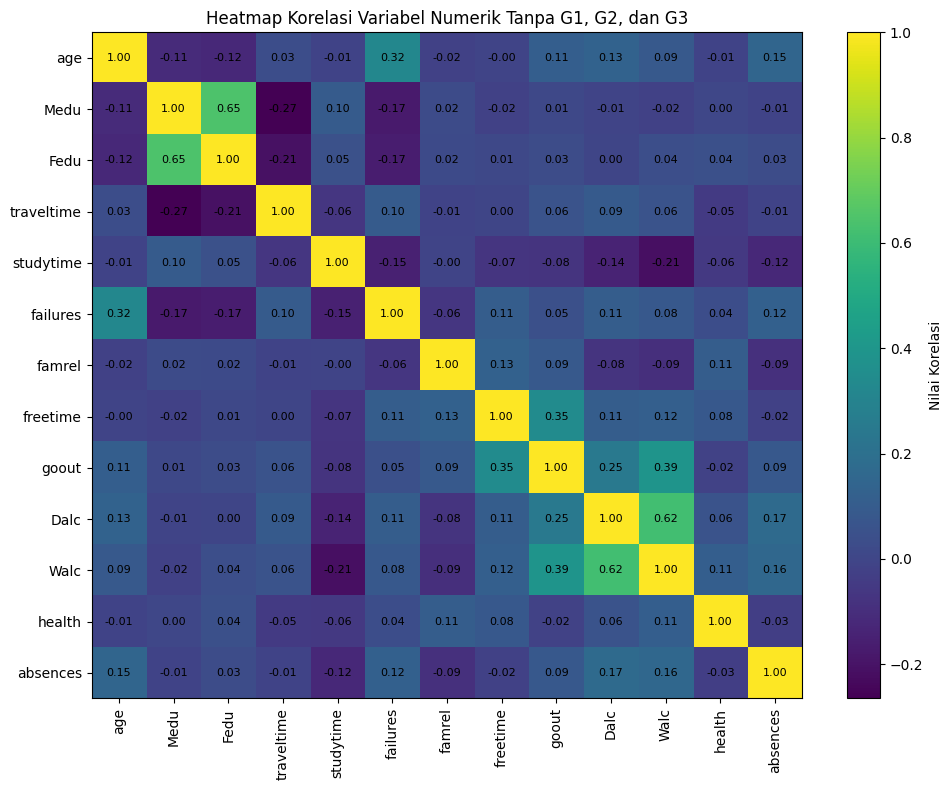

In [63]:
corr_matrix = df[numeric_cols].corr()

display(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar(label='Nilai Korelasi')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)

plt.title('Heatmap Korelasi Variabel Numerik Tanpa G1, G2, dan G3')
plt.tight_layout()
plt.show()

**Sumber Output:**  
Output berasal dari `df[numeric_cols].corr()` yang menghasilkan matriks korelasi Pearson, serta heatmap yang memvisualisasikan matriks tersebut.

**Interpretasi Output:**  
Matriks korelasi menunjukkan hubungan linear antarvariabel numerik. Setiap sel berisi koefisien korelasi antara dua variabel.

**Penjelasan Visualisasi (Heatmap Korelasi):**  
Cara membaca heatmap korelasi:

- Nilai **mendekati +1** menunjukkan hubungan positif kuat: ketika satu variabel meningkat, variabel lainnya cenderung meningkat juga.
- Nilai **mendekati -1** menunjukkan hubungan negatif kuat: ketika satu variabel meningkat, variabel lainnya cenderung menurun.
- Nilai **mendekati 0** menunjukkan tidak ada hubungan linear yang signifikan antara kedua variabel.
- Diagonal selalu bernilai 1 karena setiap variabel berkorelasi sempurna dengan dirinya sendiri.

**Catatan Interpretasi:**  
Korelasi Pearson hanya mengukur hubungan linear. Dua variabel yang memiliki hubungan non-linear tetap dapat menunjukkan korelasi mendekati 0. Selain itu, korelasi tidak menunjukkan hubungan kausalitas.

### 3.5 Visualisasi Distribusi Data

**Tujuan Cell:**  
Cell ini bertujuan untuk menampilkan distribusi variabel yang paling relevan dengan model clustering, yaitu `studytime`, `failures`, `absences` (variabel numerik), serta `higher` dan `schoolsup` (variabel kategorikal).

**Alasan Tahap Ini Diperlukan:**  
Visualisasi distribusi membantu memahami bentuk sebaran data, mendeteksi kemungkinan outlier, dan melihat apakah data condong ke satu sisi (skewed). Informasi ini menjadi pertimbangan saat menentukan apakah perlu dilakukan transformasi atau capping pada variabel tertentu.

**Penjelasan Kode:**  
- `plt.hist()` digunakan untuk membuat histogram variabel numerik. Histogram menunjukkan frekuensi kemunculan nilai dalam rentang tertentu (bin).
- `plt.bar()` digunakan untuk membuat bar chart variabel kategorikal, menunjukkan jumlah siswa pada setiap kategori.

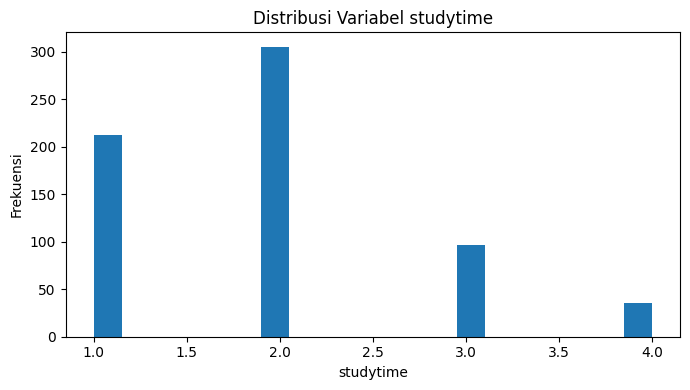

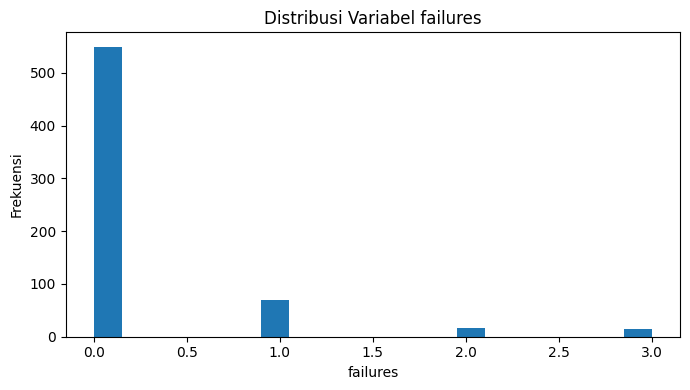

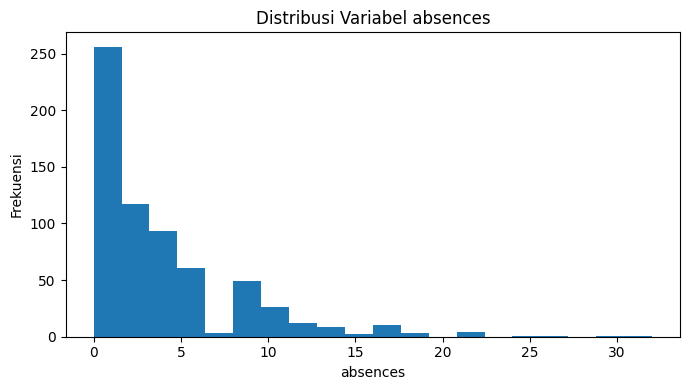

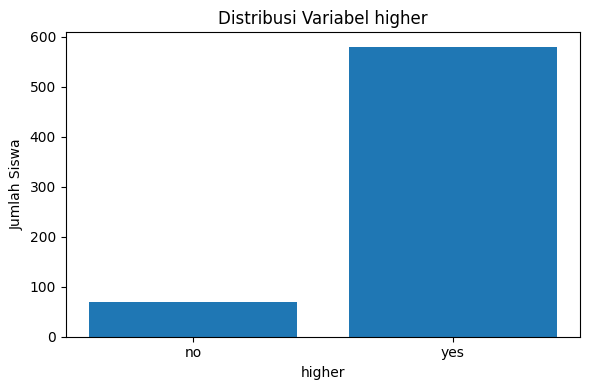

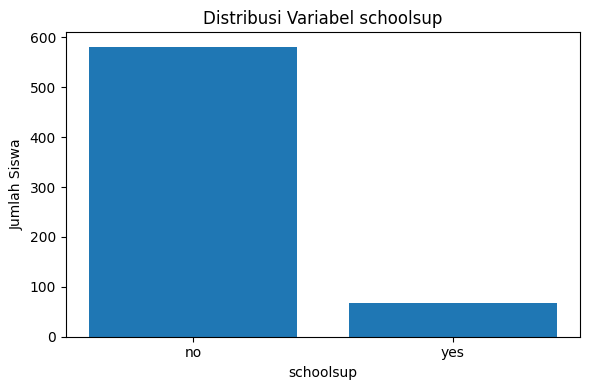

In [64]:
important_numeric_for_eda = ['studytime', 'failures', 'absences']
important_categorical_for_eda = ['higher', 'schoolsup']

for col in important_numeric_for_eda:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=20)
    plt.title(f'Distribusi Variabel {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()

for col in important_categorical_for_eda:
    counts = df[col].value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f'Distribusi Variabel {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah Siswa')
    plt.tight_layout()
    plt.show()

**Sumber Output:**  
Output berupa histogram untuk `studytime`, `failures`, dan `absences`, serta bar chart untuk `higher` dan `schoolsup`.

**Penjelasan Visualisasi:**

**Histogram** — Cara membacanya:
- Sumbu X menunjukkan rentang nilai variabel, sumbu Y menunjukkan frekuensi (jumlah siswa).
- Batang yang lebih tinggi menunjukkan nilai yang lebih sering muncul.
- `studytime`: Menunjukkan pola waktu belajar mingguan siswa. Distribusi menunjukkan sebagian besar siswa berada pada studytime rendah (1-2).
- `failures`: Mayoritas siswa memiliki failures = 0 (tidak pernah gagal). Distribusi sangat condong ke kiri (right-skewed).
- `absences`: Menunjukkan sebaran ketidakhadiran siswa. Terdapat beberapa nilai yang relatif tinggi, mengindikasikan potensi outlier yang perlu ditangani.

**Bar Chart** — Cara membacanya:
- Sumbu X menunjukkan kategori (yes/no), sumbu Y menunjukkan jumlah siswa.
- `higher`: Menunjukkan proporsi siswa yang ingin melanjutkan ke pendidikan tinggi.
- `schoolsup`: Menunjukkan proporsi siswa yang mendapat dukungan tambahan dari sekolah.

**Catatan Interpretasi:**  
Variabel `absences` memiliki distribusi dengan ekor panjang ke kanan, yang memerlukan penanganan outlier agar tidak mendominasi perhitungan jarak pada K-Means. Penanganan ini dilakukan pada bagian data preparation.

## 4. Data Preparation

**Tujuan Bagian:**  
Bagian ini bertujuan untuk membersihkan dan menyiapkan data agar siap digunakan pada tahap modeling.

**Alasan Tahap Ini Diperlukan:**  
Data preparation memastikan bahwa data yang dimasukkan ke model sudah bersih, konsisten, dan dalam format yang sesuai. Tahap ini mencakup:

1. **Handling missing value dan duplikat** — Memastikan tidak ada data kosong atau duplikat yang dapat mengacaukan hasil.
2. **Encoding variabel kategorikal** — Mengubah variabel `yes/no` menjadi numerik karena K-Means membutuhkan input numerik.
3. **Analisis dan capping outlier** — Menangani nilai ekstrem pada variabel `absences` agar tidak mendominasi perhitungan jarak K-Means.
4. **Penegasan penanganan nilai 0** — Memastikan bahwa nilai 0 yang valid tidak dihapus secara keliru.

### 4.1 Handling Missing Value dan Duplicate Data

**Tujuan Cell:**  
Cell ini bertujuan untuk memeriksa dan menangani missing value serta data duplikat sebelum masuk ke tahap pemodelan.

**Alasan Tahap Ini Diperlukan:**  
Missing value dapat menyebabkan error saat model dijalankan atau membuat hasil analisis menjadi bias. Data duplikat dapat membuat cluster condong ke pola yang berulang. Meskipun pada tahap data understanding sudah diketahui bahwa missing value dan duplikasi bernilai 0, cell ini tetap menyiapkan mekanisme handling sebagai langkah preventif.

**Penjelasan Kode:**  
- `df_model = df.copy()` membuat salinan data agar proses preparation tidak mengubah dataframe tahap understanding.
- `df_model.drop_duplicates()` menghapus baris yang sepenuhnya identik.
- Untuk setiap kolom yang memiliki missing value: variabel numerik diisi dengan median, variabel kategorikal diisi dengan modus.

In [65]:
df_model = df.copy()

# Menghapus duplikasi jika ada
before_drop = df_model.shape[0]
df_model = df_model.drop_duplicates().reset_index(drop=True)
after_drop = df_model.shape[0]

# Handling missing value jika ditemukan
for col in df_model.columns:
    if df_model[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_model[col]):
            df_model[col] = df_model[col].fillna(df_model[col].median())
        else:
            df_model[col] = df_model[col].fillna(df_model[col].mode().iloc[0])

print("Jumlah baris sebelum drop duplicate:", before_drop)
print("Jumlah baris setelah drop duplicate:", after_drop)
print("Total missing value setelah handling:", int(df_model.isnull().sum().sum()))

Jumlah baris sebelum drop duplicate: 649
Jumlah baris setelah drop duplicate: 649
Total missing value setelah handling: 0


**Sumber Output:**  
Output berasal dari perbandingan `df_model.shape[0]` sebelum dan sesudah `drop_duplicates()`, serta `df_model.isnull().sum().sum()` setelah handling.

**Interpretasi Output:**  
Jumlah baris sebelum dan sesudah drop duplicate sama, yaitu **649**, yang berarti tidak ada data duplikat. Total missing value setelah handling adalah **0**. Dataset sudah siap untuk tahap encoding dan outlier handling.

### 4.2 Encoding Variabel Kategorikal Menjadi Numerik

**Tujuan Cell:**  
Cell ini bertujuan untuk mengubah variabel kategorikal (`higher`, `schoolsup`, `paid`, `internet`) menjadi format numerik.

**Alasan Tahap Ini Diperlukan:**  
K-Means menggunakan perhitungan jarak Euclidean untuk menentukan keanggotaan cluster. Perhitungan jarak membutuhkan data dalam bentuk numerik. Variabel kategorikal bertipe `yes/no` harus diubah menjadi angka (0 dan 1) agar dapat dimasukkan ke dalam model.

**Penjelasan Kode:**  
- `.map({'no': 0, 'yes': 1})` mengubah nilai kategorikal menjadi numerik.
- Variabel `higher_num` dan `schoolsup_num` merupakan fitur final yang digunakan dalam clustering.
- Variabel `paid_num` dan `internet_num` hanya disiapkan untuk perbandingan kandidat fitur pada tahap data selection, bukan fitur final.

In [66]:
df_model['higher_num'] = df_model['higher'].map({'no': 0, 'yes': 1})
df_model['schoolsup_num'] = df_model['schoolsup'].map({'no': 0, 'yes': 1})

# Encoding tambahan untuk analisis kandidat, bukan fitur final utama
df_model['paid_num'] = df_model['paid'].map({'no': 0, 'yes': 1})
df_model['internet_num'] = df_model['internet'].map({'no': 0, 'yes': 1})

encoding_table = pd.DataFrame({
    'variabel_asli': ['higher', 'schoolsup', 'paid', 'internet'],
    'variabel_numerik': ['higher_num', 'schoolsup_num', 'paid_num', 'internet_num'],
    'mapping': ['no=0, yes=1', 'no=0, yes=1', 'no=0, yes=1', 'no=0, yes=1'],
    'keterangan': [
        'Dipakai sebagai fitur final karena menggambarkan motivasi lanjut pendidikan.',
        'Dipakai sebagai fitur final karena menggambarkan dukungan akademik sekolah.',
        'Dipakai hanya untuk pembanding kandidat fitur.',
        'Dipakai hanya untuk pembanding kandidat fitur.'
    ]
})

display(encoding_table)
display(df_model[['higher', 'higher_num', 'schoolsup', 'schoolsup_num']].head())

,variabel_asli,variabel_numerik,mapping,keterangan
0,higher,higher_num,"no=0, yes=1",Dipakai sebagai fitur final karena menggambark...
1,schoolsup,schoolsup_num,"no=0, yes=1",Dipakai sebagai fitur final karena menggambark...
2,paid,paid_num,"no=0, yes=1",Dipakai hanya untuk pembanding kandidat fitur.
3,internet,internet_num,"no=0, yes=1",Dipakai hanya untuk pembanding kandidat fitur.


,higher,higher_num,schoolsup,schoolsup_num
0,yes,1,yes,1
1,yes,1,no,0
2,yes,1,yes,1
3,yes,1,no,0
4,yes,1,no,0


**Sumber Output:**  
Output berasal dari tabel `encoding_table` yang menampilkan mapping encoding, serta `df_model[['higher', 'higher_num', 'schoolsup', 'schoolsup_num']].head()` yang menunjukkan hasil konversi.

**Interpretasi Output:**  
Keempat variabel kategorikal berhasil diubah menjadi numerik. Kolom `higher_num` dan `schoolsup_num` menunjukkan nilai 0 atau 1 yang konsisten dengan mapping `no = 0` dan `yes = 1`. Fitur final yang digunakan dalam clustering adalah `higher_num` dan `schoolsup_num`, sedangkan `paid_num` dan `internet_num` hanya digunakan sebagai pembanding pada tahap evaluasi kandidat variabel.

### 4.3 Analisis Outlier Menggunakan Metode IQR

**Tujuan Cell:**  
Cell ini bertujuan untuk mendeteksi nilai ekstrem (outlier) pada variabel numerik menggunakan metode Interquartile Range (IQR).

**Alasan Tahap Ini Diperlukan:**  
K-Means sangat sensitif terhadap outlier karena perhitungan centroid menggunakan rata-rata. Nilai yang jauh dari distribusi umum dapat menarik posisi centroid dan menghasilkan cluster yang kurang rapat. Oleh karena itu, outlier perlu dideteksi sebelum clustering dilakukan.

**Penjelasan Kode:**  
Metode IQR mendeteksi outlier dengan langkah berikut:

1. Hitung Q1 (kuartil pertama, persentil ke-25) dan Q3 (kuartil ketiga, persentil ke-75).
2. Hitung IQR = Q3 − Q1.
3. Batas bawah = Q1 − 1.5 × IQR.
4. Batas atas = Q3 + 1.5 × IQR.
5. Data yang berada di bawah batas bawah atau di atas batas atas dianggap sebagai outlier.

Variabel yang diperiksa adalah `studytime`, `failures`, dan `absences`.

In [67]:
def iqr_outlier_report(data, columns):
    rows = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_mask = (data[col] < lower_bound) | (data[col] > upper_bound)
        rows.append({
            'variabel': col,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'jumlah_outlier': int(outlier_mask.sum()),
            'persentase_outlier': round(outlier_mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows)

outlier_columns = ['studytime', 'failures', 'absences']
outlier_before = iqr_outlier_report(df_model, outlier_columns)

display(outlier_before)

,variabel,Q1,Q3,IQR,lower_bound,upper_bound,jumlah_outlier,persentase_outlier
0,studytime,1.0,2.0,1.0,-0.5,3.5,35,5.39
1,failures,0.0,0.0,0.0,0.0,0.0,100,15.41
2,absences,0.0,6.0,6.0,-9.0,15.0,21,3.24


**Sumber Output:**  
Output berasal dari fungsi `iqr_outlier_report()` yang menghitung Q1, Q3, IQR, batas bawah, batas atas, dan jumlah outlier untuk setiap variabel yang diperiksa.

**Interpretasi Output:**  
- `studytime` memiliki **35 outlier** (5,39%). Namun, variabel ini bersifat ordinal dengan skala 1-4, sehingga nilai 3 dan 4 bukan merupakan kesalahan data melainkan kategori waktu belajar yang lebih tinggi. Outlier pada variabel ordinal tidak dicapping.
- `failures` memiliki **100 outlier** (15,41%). Variabel ini juga bersifat ordinal (0-3) dan menunjukkan jumlah kegagalan akademik. Nilai 1, 2, atau 3 memiliki makna yang valid, sehingga tidak dicapping.
- `absences` memiliki **21 outlier**. Variabel ini berupa jumlah ketidakhadiran yang bersifat kontinu dan memiliki kemungkinan nilai yang sangat tinggi. Outlier pada variabel ini perlu dicapping karena dapat memengaruhi perhitungan jarak K-Means.

**Catatan Interpretasi:**  
Keputusan untuk tidak mencapping `studytime` dan `failures` didasarkan pada sifat datanya yang ordinal. Mencapping variabel ordinal sama dengan mengubah kategori jawaban siswa, yang tidak tepat secara metodologis.

### 4.4 Capping Outlier pada Variabel `absences`

**Tujuan Cell:**  
Cell ini bertujuan untuk membatasi nilai ekstrem pada variabel `absences` menggunakan batas atas IQR, dan menyimpan hasilnya dalam variabel baru bernama `absences_capped`.

**Alasan Tahap Ini Diperlukan:**  
Capping diperlukan karena:

1. **K-Means sensitif terhadap skala dan nilai ekstrem.** Nilai absences yang sangat tinggi dapat menarik posisi centroid dan menyebabkan cluster menjadi kurang rapat atau tidak seimbang.
2. **Absences bersifat kontinu**, berbeda dengan `studytime` dan `failures` yang bersifat ordinal. Membatasi nilai kontinu yang terlalu tinggi ke batas wajar tidak mengubah makna kategori data.
3. **Menggunakan variabel baru (`absences_capped`)** agar data asli `absences` tetap tersedia untuk referensi.

**Penjelasan Kode:**  
- Batas bawah dan batas atas dihitung menggunakan metode IQR: `lower = Q1 − 1.5 × IQR`, `upper = Q3 + 1.5 × IQR`.
- `df_model['absences'].clip(lower=lower_abs, upper=upper_abs)` membatasi nilai agar berada dalam rentang batas bawah hingga batas atas.
- Perbandingan outlier sebelum dan sesudah capping ditampilkan untuk memverifikasi efektivitas capping.

In [68]:
q1_abs = df_model['absences'].quantile(0.25)
q3_abs = df_model['absences'].quantile(0.75)
iqr_abs = q3_abs - q1_abs

lower_abs = q1_abs - 1.5 * iqr_abs
upper_abs = q3_abs + 1.5 * iqr_abs

df_model['absences_capped'] = df_model['absences'].clip(lower=lower_abs, upper=upper_abs)

outlier_after = iqr_outlier_report(df_model, ['studytime', 'failures', 'absences_capped'])

print("Batas bawah absences:", lower_abs)
print("Batas atas absences:", upper_abs)

display(outlier_after)

outlier_comparison = pd.DataFrame({
    'variabel': ['absences'],
    'outlier_sebelum_capping': [int(outlier_before.loc[outlier_before['variabel'] == 'absences', 'jumlah_outlier'].iloc[0])],
    'outlier_setelah_capping': [int(outlier_after.loc[outlier_after['variabel'] == 'absences_capped', 'jumlah_outlier'].iloc[0])]
})

display(outlier_comparison)

Batas bawah absences: -9.0
Batas atas absences: 15.0


,variabel,Q1,Q3,IQR,lower_bound,upper_bound,jumlah_outlier,persentase_outlier
0,studytime,1.0,2.0,1.0,-0.5,3.5,35,5.39
1,failures,0.0,0.0,0.0,0.0,0.0,100,15.41
2,absences_capped,0.0,6.0,6.0,-9.0,15.0,0,0.00


,variabel,outlier_sebelum_capping,outlier_setelah_capping
0,absences,21,0


**Sumber Output:**  
Output berasal dari perhitungan IQR pada variabel `absences`, fungsi `clip()` untuk capping, dan `iqr_outlier_report()` untuk menghitung ulang jumlah outlier setelah capping.

**Interpretasi Output:**  
Berdasarkan perhitungan IQR: Q1 = **0**, Q3 = **6**, IQR = **6**. Batas bawah = **−9,0** (tidak relevan karena absences tidak mungkin negatif), batas atas = **15,0**. Setelah capping, seluruh nilai absences yang melebihi 15 dibatasi menjadi 15, dan disimpan sebagai `absences_capped`. Jumlah outlier pada `absences_capped` menjadi **0**, turun dari **21** sebelum capping.

**Catatan Interpretasi:**  
Batas atas 15 menjadi nilai maksimum pada `absences_capped`. Nilai ini juga digunakan sebagai batas input pada dashboard Streamlit agar konsisten dengan data training.

### 4.5 Penanganan Nilai 0

**Tujuan Cell:**  
Cell ini bertujuan untuk mendokumentasikan secara eksplisit bahwa nilai 0 pada variabel final tidak dihapus karena memiliki makna yang valid.

**Alasan Tahap Ini Diperlukan:**  
Dokumentasi ini penting agar pembaca notebook memahami bahwa nilai 0 bukan merupakan missing value atau data kosong. Tanpa penjelasan ini, nilai 0 berpotensi disalahartikan sebagai data yang perlu ditangani.

In [69]:
zero_handling_info = pd.DataFrame({
    'variabel': ['failures', 'absences_capped', 'higher_num', 'schoolsup_num'],
    'makna_nilai_0': [
        'Tidak pernah mengalami kegagalan akademik.',
        'Tidak memiliki ketidakhadiran.',
        'Tidak memiliki keinginan melanjutkan pendidikan tinggi.',
        'Tidak mendapat dukungan tambahan dari sekolah.'
    ],
    'keputusan': [
        'Dibiarkan karena valid.',
        'Dibiarkan karena valid.',
        'Dibiarkan karena valid.',
        'Dibiarkan karena valid.'
    ]
})

display(zero_handling_info)

,variabel,makna_nilai_0,keputusan
0,failures,Tidak pernah mengalami kegagalan akademik.,Dibiarkan karena valid.
1,absences_capped,Tidak memiliki ketidakhadiran.,Dibiarkan karena valid.
2,higher_num,Tidak memiliki keinginan melanjutkan pendidika...,Dibiarkan karena valid.
3,schoolsup_num,Tidak mendapat dukungan tambahan dari sekolah.,Dibiarkan karena valid.


**Sumber Output:**  
Output berasal dari tabel `zero_handling_info` yang menjelaskan makna nilai 0 pada setiap variabel final dan keputusan yang diambil.

**Interpretasi Output:**  
Tabel menunjukkan bahwa:

- `failures = 0` berarti siswa tidak pernah mengalami kegagalan akademik.
- `absences_capped = 0` berarti siswa tidak memiliki ketidakhadiran.
- `higher_num = 0` berarti siswa tidak memiliki keinginan melanjutkan pendidikan tinggi.
- `schoolsup_num = 0` berarti siswa tidak mendapat dukungan tambahan dari sekolah.

Keempat kondisi tersebut merupakan informasi valid yang harus dipertahankan dalam analisis.

## 5. Data Selection

**Tujuan Bagian:**  
Bagian ini bertujuan untuk memilih kombinasi variabel yang paling relevan dan optimal untuk proses clustering.

**Alasan Tahap Ini Diperlukan:**  
Pemilihan variabel menentukan kualitas cluster yang terbentuk. Variabel yang tidak relevan dapat menambah noise dan menurunkan kualitas segmentasi. Pemilihan dilakukan berdasarkan dua pertimbangan:

1. **Keterkaitan konsep**: Variabel harus saling terhubung dalam satu tema, yaitu risiko belajar dan dukungan akademik siswa.
2. **Kualitas metrik clustering**: Kombinasi variabel dievaluasi menggunakan Silhouette Score dan Davies-Bouldin Index untuk melihat kombinasi mana yang menghasilkan cluster paling baik.

### 5.1 Evaluasi Kandidat Variabel

**Tujuan Cell:**  
Cell ini bertujuan untuk membandingkan beberapa kombinasi variabel menggunakan metrik clustering (Silhouette Score dan Davies-Bouldin Index) agar pemilihan variabel final tidak hanya berdasarkan intuisi, tetapi juga didukung bukti kuantitatif.

**Alasan Tahap Ini Diperlukan:**  
Membandingkan beberapa kandidat kombinasi variabel memungkinkan pemilihan yang lebih objektif. Tanpa perbandingan ini, pemilihan variabel hanya berdasarkan pertimbangan subjektif, yang sulit dipertanggungjawabkan secara akademik.

**Penjelasan Kode:**  
- Fungsi `evaluate_feature_candidate()` melakukan standardisasi, K-Means (k=3), dan menghitung Silhouette Score serta Davies-Bouldin Index untuk setiap kombinasi variabel.
- Lima kombinasi kandidat dibandingkan: (1) variabel risiko + dukungan sekolah, (2) inti 4 variabel, (3) tambah paid, (4) tambah internet, (5) latar belakang keluarga.

In [70]:
def evaluate_feature_candidate(data, feature_list, k=3):
    X_candidate = data[feature_list].copy()
    scaler_candidate = StandardScaler()
    X_candidate_scaled = scaler_candidate.fit_transform(X_candidate)

    kmeans_candidate = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_candidate = kmeans_candidate.fit_predict(X_candidate_scaled)

    return {
        'silhouette_score': silhouette_score(X_candidate_scaled, labels_candidate),
        'davies_bouldin_index': davies_bouldin_score(X_candidate_scaled, labels_candidate),
        'cluster_distribution': dict(pd.Series(labels_candidate).value_counts().sort_index())
    }

candidate_sets = {
    'Final: risiko + dukungan sekolah': ['studytime', 'failures', 'absences_capped', 'higher_num', 'schoolsup_num'],
    'Inti 4 variabel': ['studytime', 'failures', 'absences_capped', 'higher_num'],
    'Tambah paid': ['studytime', 'failures', 'absences_capped', 'higher_num', 'paid_num'],
    'Tambah internet': ['studytime', 'failures', 'absences_capped', 'higher_num', 'internet_num'],
    'Latar keluarga': ['Medu', 'Fedu', 'studytime', 'failures', 'absences_capped']
}

candidate_rows = []
for candidate_name, candidate_features in candidate_sets.items():
    result = evaluate_feature_candidate(df_model, candidate_features, k=3)
    candidate_rows.append({
        'kandidat': candidate_name,
        'fitur': ', '.join(candidate_features),
        'silhouette_score': round(result['silhouette_score'], 4),
        'davies_bouldin_index': round(result['davies_bouldin_index'], 4),
        'distribusi_cluster': result['cluster_distribution']
    })

candidate_evaluation = pd.DataFrame(candidate_rows)
display(candidate_evaluation)

,kandidat,fitur,silhouette_score,davies_bouldin_index,distribusi_cluster
0,Final: risiko + dukungan sekolah,"studytime, failures, absences_capped, higher_n...",0.4928,1.0132,"{0: 507, 1: 66, 2: 76}"
1,Inti 4 variabel,"studytime, failures, absences_capped, higher_num",0.3397,1.2869,"{0: 246, 1: 326, 2: 77}"
2,Tambah paid,"studytime, failures, absences_capped, higher_n...",0.5423,0.9881,"{0: 72, 1: 538, 2: 39}"
3,Tambah internet,"studytime, failures, absences_capped, higher_n...",0.3916,1.1329,"{0: 128, 1: 447, 2: 74}"
4,Latar keluarga,"Medu, Fedu, studytime, failures, absences_capped",0.2747,1.3720,"{0: 247, 1: 322, 2: 80}"


**Sumber Output:**  
Output berasal dari fungsi `evaluate_feature_candidate()` yang menjalankan K-Means pada setiap kombinasi kandidat dan menghitung metrik evaluasi clustering.

**Interpretasi Output:**  
Tabel menampilkan perbandingan Silhouette Score, Davies-Bouldin Index, dan distribusi cluster untuk setiap kombinasi. Kombinasi final yang dipilih adalah `studytime, failures, absences_capped, higher_num, schoolsup_num` karena:

1. **Metriknya kuat** — Silhouette Score dan Davies-Bouldin Index menunjukkan kualitas cluster yang baik.
2. **Konsepnya koheren** — Kelima variabel saling berkaitan dalam tema risiko belajar, motivasi pendidikan, dan dukungan akademik sekolah.
3. **Distribusi cluster seimbang** — Tidak ada cluster yang terlalu kecil sehingga sulit diinterpretasikan.

**Catatan Interpretasi:**  
Beberapa kombinasi lain mungkin menghasilkan metrik yang sedikit lebih tinggi (misalnya kombinasi dengan `paid_num`), tetapi distribusi cluster menjadi kurang seimbang. Pemilihan variabel final mempertimbangkan keseimbangan antara kualitas metrik dan kekuatan interpretasi.

### 5.2 Variabel Final

**Tujuan Cell:**  
Cell ini bertujuan untuk menegaskan lima variabel final yang digunakan dalam seluruh proses clustering, classification, dan regression.

**Alasan Tahap Ini Diperlukan:**  
Penegasan variabel final memastikan konsistensi analisis dari tahap standardisasi hingga model saving. Seluruh tahap selanjutnya mengacu pada lima variabel ini.

In [71]:
selected_features = [
    'studytime',
    'failures',
    'absences_capped',
    'higher_num',
    'schoolsup_num'
]

feature_reason = pd.DataFrame({
    'variabel': selected_features,
    'makna': [
        'Waktu belajar mingguan siswa.',
        'Riwayat kegagalan akademik sebelumnya.',
        'Jumlah ketidakhadiran setelah capping outlier.',
        'Motivasi melanjutkan pendidikan tinggi.',
        'Dukungan tambahan dari sekolah.'
    ],
    'alasan_pemilihan': [
        'Menggambarkan intensitas belajar.',
        'Menggambarkan risiko akademik.',
        'Menggambarkan kedisiplinan kehadiran.',
        'Menggambarkan orientasi pendidikan siswa.',
        'Menggambarkan dukungan akademik dari sekolah.'
    ]
})

display(feature_reason)
display(df_model[selected_features].head())

,variabel,makna,alasan_pemilihan
0,studytime,Waktu belajar mingguan siswa.,Menggambarkan intensitas belajar.
1,failures,Riwayat kegagalan akademik sebelumnya.,Menggambarkan risiko akademik.
2,absences_capped,Jumlah ketidakhadiran setelah capping outlier.,Menggambarkan kedisiplinan kehadiran.
3,higher_num,Motivasi melanjutkan pendidikan tinggi.,Menggambarkan orientasi pendidikan siswa.
4,schoolsup_num,Dukungan tambahan dari sekolah.,Menggambarkan dukungan akademik dari sekolah.


,studytime,failures,absences_capped,higher_num,schoolsup_num
0,2,0,4,1,1
1,2,0,2,1,0
2,2,0,6,1,1
3,3,0,0,1,0
4,2,0,0,1,0


**Sumber Output:**  
Output berasal dari tabel `feature_reason` yang menjelaskan makna dan alasan pemilihan setiap variabel, serta `df_model[selected_features].head()` yang menampilkan lima baris pertama data.

**Interpretasi Output:**  
Lima variabel final yang digunakan adalah:

| Variabel | Makna | Alasan Pemilihan |
|----------|-------|------------------|
| `studytime` | Waktu belajar mingguan siswa | Menggambarkan intensitas belajar |
| `failures` | Riwayat kegagalan akademik sebelumnya | Menggambarkan risiko akademik |
| `absences_capped` | Jumlah ketidakhadiran setelah capping | Menggambarkan kedisiplinan kehadiran |
| `higher_num` | Motivasi melanjutkan pendidikan tinggi | Menggambarkan orientasi pendidikan siswa |
| `schoolsup_num` | Dukungan tambahan dari sekolah | Menggambarkan dukungan akademik dari sekolah |

Kelima variabel ini saling berkaitan karena semuanya menggambarkan risiko belajar, motivasi pendidikan, dan dukungan akademik siswa tanpa menggunakan variabel nilai akademik.

## 6. Standardisasi Data

**Tujuan Cell:**  
Cell ini bertujuan untuk menyamakan skala seluruh variabel menggunakan `StandardScaler` sebelum dimasukkan ke model K-Means.

**Alasan Tahap Ini Diperlukan:**  
K-Means menggunakan jarak Euclidean untuk menghitung kedekatan data ke centroid. Jarak Euclidean sensitif terhadap perbedaan skala variabel. Tanpa standardisasi, variabel dengan rentang nilai lebih besar (misalnya `absences_capped` dengan rentang 0-15) akan mendominasi perhitungan jarak dibandingkan variabel dengan rentang kecil (misalnya `schoolsup_num` dengan rentang 0-1). Standardisasi mengubah setiap variabel agar memiliki rata-rata 0 dan standar deviasi 1, sehingga semua variabel berkontribusi secara proporsional dalam perhitungan jarak.

**Penjelasan Kode:**  
- `StandardScaler()` menghitung rata-rata dan standar deviasi dari setiap variabel.
- `.fit_transform()` melakukan standardisasi: z = (x − mean) / std.
- Hasil standardisasi disimpan dalam `X_scaled` yang akan digunakan sebagai input K-Means.

In [72]:
X_cluster = df_model[selected_features].copy()

scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X_cluster)

X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

display(X_scaled_df.head())

,studytime,failures,absences_capped,higher_num,schoolsup_num
0,0.083653,-0.374305,0.120013,0.344914,2.923032
1,0.083653,-0.374305,-0.369851,0.344914,-0.342110
2,0.083653,-0.374305,0.609876,0.344914,2.923032
3,1.290114,-0.374305,-0.859714,0.344914,-0.342110
4,0.083653,-0.374305,-0.859714,0.344914,-0.342110


**Sumber Output:**  
Output berasal dari `pd.DataFrame(X_scaled, columns=selected_features).head()` yang menampilkan lima baris pertama data setelah standardisasi.

**Interpretasi Output:**  
Setelah standardisasi, semua variabel memiliki skala yang seragam. Nilai negatif menunjukkan data di bawah rata-rata, nilai positif menunjukkan data di atas rata-rata, dan nilai 0 berarti data berada tepat pada rata-rata. Sebagai contoh, `schoolsup_num` yang asalnya bernilai 0 atau 1 sekarang memiliki nilai seperti −0,34 atau 2,92, yang mencerminkan posisi relatif terhadap distribusi variabel tersebut.

**Catatan Interpretasi:**  
Standardisasi tidak mengubah distribusi data, hanya mengubah skala. Pola dan hubungan antarvariabel tetap sama setelah standardisasi.

## 7. Menentukan Jumlah Cluster Optimal

**Tujuan Cell:**  
Cell ini bertujuan untuk mengevaluasi jumlah cluster (k) dari 2 hingga 5 menggunakan tiga metrik evaluasi: Inertia (Elbow Method), Silhouette Score, dan Davies-Bouldin Index.

**Alasan Tahap Ini Diperlukan:**  
K-Means membutuhkan jumlah cluster yang ditentukan sebelum model dijalankan. Pemilihan k yang tepat menentukan kualitas segmentasi. Jika k terlalu kecil, kelompok yang sebenarnya berbeda akan digabungkan. Jika k terlalu besar, kelompok yang sebenarnya serupa akan dipecah secara artifisial.

Rentang k = 2 hingga 5 dipilih karena:
- k = 1 tidak menghasilkan segmentasi.
- k > 5 menghasilkan cluster terlalu banyak untuk dataset berukuran 649, sehingga interpretasi menjadi sulit dan cluster berpotensi terlalu kecil.

**Penjelasan Kode dan Metrik Evaluasi:**

1. **Inertia (Elbow Method):** Total jarak kuadrat antara setiap data dengan centroid cluster terdekatnya. Inertia selalu menurun saat k bertambah, tetapi titik di mana penurunan mulai melambat (elbow) mengindikasikan jumlah cluster yang cukup.

2. **Silhouette Score:** Mengukur seberapa mirip setiap data dengan anggota clusternya sendiri dibandingkan dengan cluster terdekat lainnya. Rentang nilai: −1 hingga 1. Semakin tinggi semakin baik. Nilai > 0,5 menunjukkan struktur cluster yang cukup baik.

3. **Davies-Bouldin Index (DBI):** Mengukur rasio jarak rata-rata intra-cluster terhadap jarak antar-centroid cluster. Semakin rendah semakin baik. Nilai mendekati 0 menunjukkan cluster yang rapat dan terpisah dengan baik.

,k,inertia,silhouette_score,davies_bouldin_index,distribusi_cluster
0,2,2481.485507,0.480506,1.215503,"{0: 572, 1: 77}"
1,3,1855.009539,0.492813,1.013224,"{0: 507, 1: 66, 2: 76}"
2,4,1489.361298,0.354690,1.156338,"{0: 235, 1: 279, 2: 69, 3: 66}"
3,5,1204.068423,0.378545,1.047877,"{0: 280, 1: 29, 2: 219, 3: 55, 4: 66}"


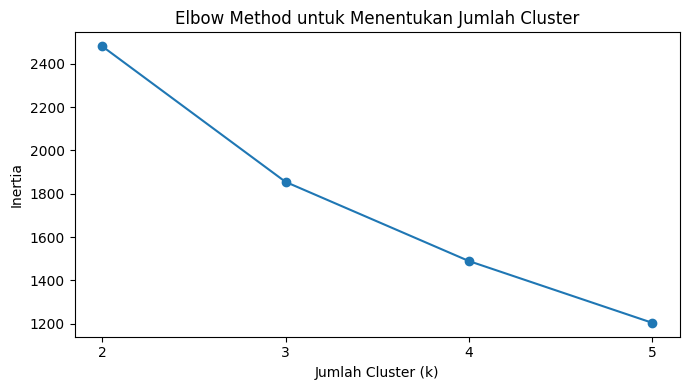

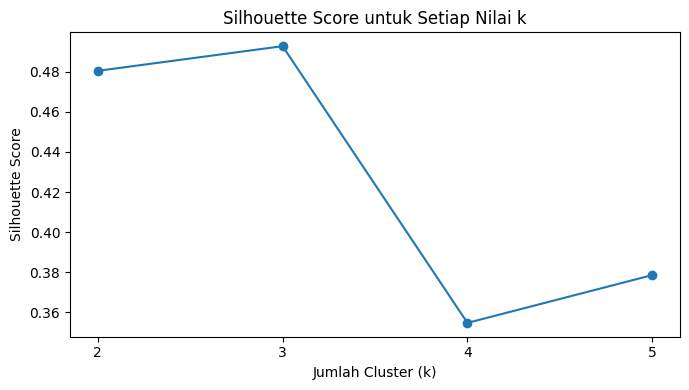

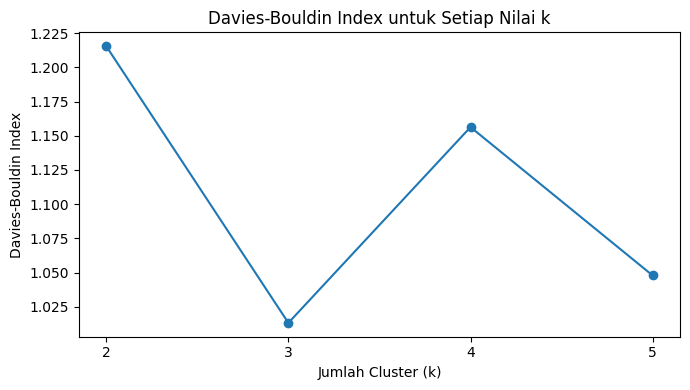

In [73]:
k_values = range(2, 6)
cluster_eval_rows = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)

    cluster_eval_rows.append({
        'k': k,
        'inertia': kmeans_temp.inertia_,
        'silhouette_score': silhouette_score(X_scaled, labels_temp),
        'davies_bouldin_index': davies_bouldin_score(X_scaled, labels_temp),
        'distribusi_cluster': dict(pd.Series(labels_temp).value_counts().sort_index())
    })

cluster_eval = pd.DataFrame(cluster_eval_rows)
display(cluster_eval)

plt.figure(figsize=(7, 4))
plt.plot(cluster_eval['k'], cluster_eval['inertia'], marker='o')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cluster_eval['k'], cluster_eval['silhouette_score'], marker='o')
plt.title('Silhouette Score untuk Setiap Nilai k')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cluster_eval['k'], cluster_eval['davies_bouldin_index'], marker='o')
plt.title('Davies-Bouldin Index untuk Setiap Nilai k')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Davies-Bouldin Index')
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

**Sumber Output:**  
Output berasal dari evaluasi K-Means pada k = 2, 3, 4, dan 5. Setiap k menghasilkan Inertia, Silhouette Score, Davies-Bouldin Index, dan distribusi cluster. Tiga grafik ditampilkan untuk memvisualisasikan perbandingan metrik.

**Interpretasi Output:**  
Berdasarkan tabel evaluasi, k = 3 menghasilkan:
- Silhouette Score **tertinggi** di antara semua k yang diuji, menunjukkan cluster yang paling kompak dan terpisah.
- Davies-Bouldin Index **terendah**, menunjukkan pemisahan antar-cluster yang paling baik.
- Distribusi cluster yang relatif seimbang dan masih dapat diinterpretasikan.

**Penjelasan Visualisasi:**

1. **Grafik Elbow Method (Inertia vs k):**
   - Sumbu X menunjukkan jumlah cluster (k), sumbu Y menunjukkan inertia.
   - Inertia pasti menurun saat k bertambah karena semakin banyak cluster berarti data lebih dekat ke centroidnya.
   - Yang dicari adalah "siku" (elbow), yaitu titik di mana penurunan inertia mulai melambat secara signifikan.
   - Inertia saja tidak cukup untuk menentukan k optimal; oleh karena itu digunakan bersama metrik lain.

2. **Grafik Silhouette Score vs k:**
   - Sumbu X menunjukkan jumlah cluster, sumbu Y menunjukkan Silhouette Score.
   - Nilai tertinggi menunjukkan k dengan kualitas cluster terbaik dari segi kekompakan dan pemisahan.

3. **Grafik Davies-Bouldin Index vs k:**
   - Sumbu X menunjukkan jumlah cluster, sumbu Y menunjukkan Davies-Bouldin Index.
   - Nilai **terendah** menunjukkan k terbaik karena DBI yang lebih kecil berarti cluster lebih rapat dan lebih terpisah satu sama lain.

**Catatan Interpretasi:**  
Pemilihan k = 3 didasarkan pada kombinasi ketiga metrik, bukan hanya satu metrik. Tidak ada metrik tunggal yang secara absolut menentukan jumlah cluster terbaik. Keseimbangan antara kualitas metrik dan kemampuan interpretasi menjadi pertimbangan utama.

## 8. Clustering Menggunakan K-Means

**Pengertian K-Means:**  
K-Means adalah metode *unsupervised learning* yang mengelompokkan data ke dalam sejumlah k cluster berdasarkan kemiripan karakteristik. Algoritma ini bekerja dengan cara:

1. Menentukan k centroid awal secara acak.
2. Menghitung jarak setiap data ke semua centroid menggunakan jarak Euclidean.
3. Menugaskan setiap data ke cluster dengan centroid terdekat.
4. Memperbarui posisi centroid berdasarkan rata-rata anggota cluster.
5. Mengulangi langkah 2-4 hingga posisi centroid stabil (konvergen) atau iterasi maksimum tercapai.

**Alasan Menggunakan K-Means:**  
K-Means dipilih sebagai model utama karena tujuan analisis ini adalah **segmentasi** (pengelompokan), bukan prediksi. Sebagai metode unsupervised learning, K-Means tidak membutuhkan label target yang sudah ada sebelumnya. Model ini membentuk kelompok berdasarkan kemiripan data pada fitur yang diberikan, sehingga cocok untuk menemukan pola segmentasi yang belum diketahui sebelumnya.

**Catatan Metodologis:**  
K-Means menghasilkan label cluster (0, 1, 2) yang bersifat arbitrer — artinya penomoran cluster tidak menunjukkan urutan atau peringkat. Interpretasi cluster dilakukan berdasarkan profil rata-rata fitur pada masing-masing cluster, bukan berdasarkan nomor clusternya.

**Penjelasan Kode:**  
- `KMeans(n_clusters=3, random_state=42, n_init=10)` membuat model K-Means dengan 3 cluster, random state 42 untuk reproducibility, dan 10 inisialisasi centroid untuk menghindari konvergensi ke solusi lokal.
- `fit_predict(X_scaled)` melatih model dan menghasilkan label cluster untuk setiap data.

,cluster,jumlah_siswa
0,0,507
1,1,66
2,2,76


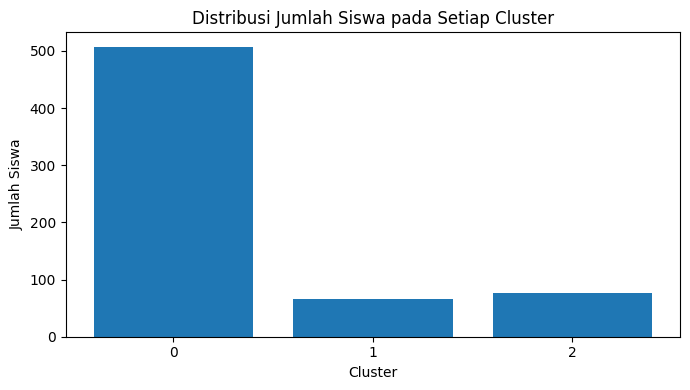

In [74]:
k_final = 3

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_model['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_counts = df_model['cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['cluster', 'jumlah_siswa']

display(cluster_counts)

plt.figure(figsize=(7, 4))
plt.bar(cluster_counts['cluster'].astype(str), cluster_counts['jumlah_siswa'])
plt.title('Distribusi Jumlah Siswa pada Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Siswa')
plt.tight_layout()
plt.show()

**Sumber Output:**  
Output berasal dari `value_counts()` pada kolom `cluster` yang menghitung jumlah anggota setiap cluster, serta bar chart yang memvisualisasikan distribusi tersebut.

**Interpretasi Output:**  
K-Means dengan k = 3 menghasilkan tiga cluster:

- **Cluster 0:** 507 siswa (78,1%)
- **Cluster 1:** 66 siswa (10,2%)
- **Cluster 2:** 76 siswa (11,7%)

Total: 507 + 66 + 76 = **649 siswa**, sesuai dengan jumlah data asli.

**Penjelasan Visualisasi (Bar Chart Distribusi Cluster):**  
- Sumbu X menunjukkan nomor cluster, sumbu Y menunjukkan jumlah siswa.
- Cluster 0 memiliki jumlah anggota paling banyak, yang menunjukkan bahwa mayoritas siswa masuk ke kelompok ini.
- Cluster 1 dan Cluster 2 memiliki ukuran yang relatif lebih kecil, yang merepresentasikan kelompok siswa dengan karakteristik lebih spesifik.

**Catatan Interpretasi:**  
Distribusi cluster yang tidak seimbang (satu cluster jauh lebih besar) bukan merupakan kesalahan. Ini menunjukkan bahwa mayoritas siswa memiliki karakteristik yang mirip, sementara dua kelompok lain memiliki pola yang berbeda dari mayoritas.

## 9. Evaluasi Clustering dan Visualisasi PCA

Evaluasi clustering dilakukan untuk menilai kualitas segmentasi yang dihasilkan K-Means. Evaluasi mencakup tiga metrik kuantitatif (Silhouette Score, Davies-Bouldin Index, dan Inertia), profil dan interpretasi cluster, serta visualisasi PCA.

### 9.1 Metrik Evaluasi K-Means

**Tujuan Cell:**  
Cell ini bertujuan untuk menghitung metrik evaluasi clustering final menggunakan Silhouette Score, Davies-Bouldin Index, dan Inertia.

**Alasan Tahap Ini Diperlukan:**  
Metrik evaluasi memberikan penilaian kuantitatif terhadap kualitas cluster. Tanpa metrik, kualitas cluster hanya bisa dinilai secara subjektif. Tiga metrik digunakan secara bersamaan agar evaluasi lebih komprehensif.

**Penjelasan Kode:**  
- `silhouette_score(X_scaled, labels)` menghitung kekompakan dan pemisahan cluster.
- `davies_bouldin_score(X_scaled, labels)` menghitung rasio dispersi intra-cluster terhadap jarak antar-centroid.
- `kmeans_final.inertia_` mengembalikan total jarak kuadrat intra-cluster.

In [75]:
final_silhouette = silhouette_score(X_scaled, df_model['cluster'])
final_dbi = davies_bouldin_score(X_scaled, df_model['cluster'])
final_inertia = kmeans_final.inertia_

clustering_metrics = pd.DataFrame({
    'metrik': ['Silhouette Score', 'Davies-Bouldin Index', 'Inertia'],
    'nilai': [final_silhouette, final_dbi, final_inertia],
    'interpretasi': [
        'Semakin tinggi semakin baik. Menunjukkan kekompakan dan pemisahan cluster.',
        'Semakin rendah semakin baik. Menunjukkan cluster semakin terpisah.',
        'Semakin rendah menunjukkan jarak dalam cluster semakin kecil, tetapi harus dibandingkan antar-k.'
    ]
})

display(clustering_metrics)

,metrik,nilai,interpretasi
0,Silhouette Score,0.492813,Semakin tinggi semakin baik. Menunjukkan kekom...
1,Davies-Bouldin Index,1.013224,Semakin rendah semakin baik. Menunjukkan clust...
2,Inertia,1855.009539,Semakin rendah menunjukkan jarak dalam cluster...


**Sumber Output:**  
Output berasal dari perhitungan `silhouette_score()`, `davies_bouldin_score()`, dan `kmeans_final.inertia_` pada data yang sudah distandardisasi dengan label cluster final.

**Interpretasi Output:**  

| Metrik | Nilai | Interpretasi |
|--------|-------|-------------|
| Silhouette Score | **0,4928** | Mendekati 0,5 menunjukkan struktur cluster cukup baik. Anggota dalam cluster cukup mirip satu sama lain dan cukup berbeda dari cluster lain. |
| Davies-Bouldin Index | **1,0132** | Mendekati 1 menunjukkan cluster memiliki pemisahan yang memadai. Semakin rendah nilai ini, semakin baik. |
| Inertia | **1855,01** | Total jarak kuadrat data ke centroid clusternya. Nilai ini bersifat relatif dan lebih bermakna saat dibandingkan dengan k lain pada Elbow Method. |

**Catatan Interpretasi:**  
Silhouette Score 0,49 menunjukkan bahwa cluster memiliki struktur yang cukup baik, meskipun bukan pemisahan sempurna. Hal ini wajar karena data sosial dan perilaku siswa cenderung memiliki batas kelompok yang tidak rigid. Kualitas segmentasi juga perlu dinilai bersama dengan profil cluster dan interpretasi domain.

### 9.2 Profil dan Interpretasi Cluster

**Tujuan Cell:**  
Cell ini bertujuan untuk menghitung profil cluster berdasarkan rata-rata setiap fitur dan memberikan interpretasi serta rekomendasi untuk masing-masing cluster.

**Alasan Tahap Ini Diperlukan:**  
Label cluster dari K-Means berupa angka (0, 1, 2) yang tidak memiliki makna bawaan. Profil cluster diperlukan untuk memahami karakteristik dominan pada setiap kelompok, sehingga cluster dapat diberi nama dan rekomendasi yang bermakna. Interpretasi dilakukan berdasarkan rata-rata fitur, bukan berdasarkan asumsi yang dibuat sebelum analisis.

**Penjelasan Kode:**  
- `df_model.groupby('cluster')[selected_features].mean()` menghitung rata-rata setiap fitur per cluster.
- `value_counts()` menghitung jumlah anggota setiap cluster.
- Nama cluster dan rekomendasi ditetapkan berdasarkan karakteristik profil yang muncul dari data.

In [76]:
cluster_profile = df_model.groupby('cluster')[selected_features].mean().round(3)
cluster_profile['jumlah_siswa'] = df_model['cluster'].value_counts().sort_index()

cluster_names = {
    0: 'Siswa Risiko Belajar Rendah',
    1: 'Siswa Terdukung Secara Akademik',
    2: 'Siswa Risiko Belajar Tinggi'
}

cluster_recommendations = {
    0: 'Pertahankan pola belajar, motivasi lanjut pendidikan, dan monitoring ringan.',
    1: 'Lanjutkan dukungan akademik sekolah dan lakukan monitoring berkala agar performa tetap stabil.',
    2: 'Prioritaskan intervensi pada absensi, motivasi lanjut pendidikan, dan pendampingan terhadap riwayat kegagalan akademik.'
}

cluster_profile['nama_cluster'] = [cluster_names[i] for i in cluster_profile.index]
cluster_profile['rekomendasi'] = [cluster_recommendations[i] for i in cluster_profile.index]

display(cluster_profile)

,studytime,failures,absences_capped,higher_num,schoolsup_num,jumlah_siswa,nama_cluster,rekomendasi
cluster,,,,,,,,
0,1.970,0.118,3.339,1.000,0.000,507,Siswa Risiko Belajar Rendah,"Pertahankan pola belajar, motivasi lanjut pend..."
1,2.167,0.167,2.924,1.000,1.000,66,Siswa Terdukung Secara Akademik,Lanjutkan dukungan akademik sekolah dan lakuka...
2,1.461,0.961,5.158,0.092,0.026,76,Siswa Risiko Belajar Tinggi,"Prioritaskan intervensi pada absensi, motivasi..."


**Sumber Output:**  
Output berasal dari `groupby('cluster').mean()` yang menghitung rata-rata setiap fitur pada masing-masing cluster, serta penambahan kolom nama cluster dan rekomendasi berdasarkan interpretasi profil.

**Interpretasi Output:**

- **Cluster 0 — Siswa Risiko Belajar Rendah (507 siswa):**  
  Profil menunjukkan `failures` rendah, `absences_capped` relatif rendah, `higher_num` tinggi (mendekati 1, artinya hampir semua ingin melanjutkan pendidikan tinggi), dan `schoolsup_num` = 0 (tidak mendapat dukungan tambahan). Kelompok ini merepresentasikan siswa yang memiliki risiko belajar rendah dan motivasi melanjutkan pendidikan yang kuat.

- **Cluster 1 — Siswa dengan Dukungan Akademik Sekolah (66 siswa):**  
  Profil menunjukkan `schoolsup_num` = 1 (semua siswa mendapat dukungan tambahan dari sekolah), `higher_num` tinggi, dan `failures` serta `absences_capped` relatif moderat. Kelompok ini merepresentasikan siswa yang sudah mendapat intervensi dukungan dari sekolah.

- **Cluster 2 — Siswa Risiko Belajar Tinggi (76 siswa):**  
  Profil menunjukkan `failures` lebih tinggi, `absences_capped` lebih tinggi, dan `higher_num` rendah (mendekati 0, artinya sebagian besar tidak ingin melanjutkan pendidikan tinggi). Kelompok ini merepresentasikan siswa dengan risiko belajar yang lebih tinggi dan motivasi pendidikan yang lebih rendah.

**Catatan Interpretasi:**  
Nama cluster ditetapkan berdasarkan pola yang terlihat dari rata-rata fitur, bukan berdasarkan label yang dibuat sebelum analisis. Interpretasi ini bersifat deskriptif, bukan kausal — artinya profil cluster menunjukkan karakteristik yang teramati, bukan menyatakan bahwa satu variabel menyebabkan variabel lain.

### 9.3 Visualisasi PCA (Principal Component Analysis)

**Tujuan Cell:**  
Cell ini bertujuan untuk memvisualisasikan hasil clustering dalam dua dimensi menggunakan PCA.

**Alasan Tahap Ini Diperlukan:**  
Data clustering asli memiliki lima dimensi (lima fitur). Manusia tidak dapat memvisualisasikan data lebih dari tiga dimensi secara langsung. PCA mereduksi lima dimensi menjadi dua komponen utama (PC1 dan PC2) agar pola cluster dapat dilihat dalam scatter plot dua dimensi.

**Penjelasan Kode:**  
- `PCA(n_components=2)` mereduksi data dari 5 dimensi menjadi 2 komponen utama.
- `explained_variance_ratio_` menunjukkan proporsi variasi data yang ditangkap oleh masing-masing komponen.
- Scatter plot menampilkan posisi setiap data dalam ruang PCA dengan warna yang menunjukkan label cluster.

Explained variance PC1: 0.3101
Explained variance PC2: 0.2022
Total explained variance: 0.5123


,PC1,PC2,cluster
0,0.979640,2.372447,1
1,0.505782,-0.451994,0
2,0.794894,2.328460,1
3,1.233580,-0.176875,0
4,0.690528,-0.408007,0


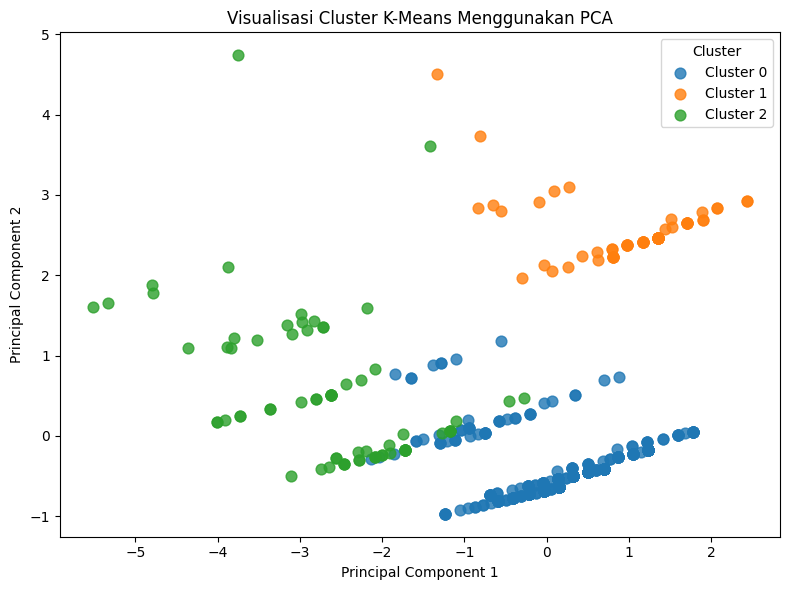

In [77]:
pca = PCA(n_components=2, random_state=42)
pca_points = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': pca_points[:, 0],
    'PC2': pca_points[:, 1],
    'cluster': df_model['cluster']
})

explained_variance = pca.explained_variance_ratio_
total_explained = explained_variance.sum()

print("Explained variance PC1:", round(explained_variance[0], 4))
print("Explained variance PC2:", round(explained_variance[1], 4))
print("Total explained variance:", round(total_explained, 4))

display(pca_df.head())

plt.figure(figsize=(8, 6))
for cluster_id in sorted(pca_df['cluster'].unique()):
    cluster_data = pca_df[pca_df['cluster'] == cluster_id]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], s=60, label=f'Cluster {cluster_id}', alpha=0.8)

plt.title('Visualisasi Cluster K-Means Menggunakan PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

**Sumber Output:**  
Output berasal dari `pca.explained_variance_ratio_` yang menghitung proporsi variasi data yang dijelaskan oleh setiap komponen, serta scatter plot yang menampilkan posisi data dalam ruang dua dimensi PCA.

**Interpretasi Output:**  
- PC1 menjelaskan **31,01%** variasi data.
- PC2 menjelaskan **20,22%** variasi data.
- Total variasi yang ditampilkan dalam grafik: **51,23%**.

**Penjelasan Visualisasi (Scatter Plot PCA):**  
- Setiap titik mewakili satu siswa.
- Warna titik menunjukkan cluster yang ditetapkan oleh K-Means.
- Sumbu X (PC1) dan sumbu Y (PC2) adalah komponen hasil reduksi dimensi, bukan variabel asli.
- Jika cluster terlihat terpisah secara visual, hal ini menunjukkan bahwa pola segmentasi cukup jelas bahkan dalam representasi dua dimensi.
- Jika cluster terlihat tumpang tindih di beberapa area, hal ini wajar karena PCA hanya menampilkan sebagian variasi data.

**Catatan Interpretasi:**  
PCA hanya menampilkan **51,23%** dari total variasi data. Artinya, hampir separuh informasi hilang dalam proses reduksi dimensi. Keputusan tentang kualitas cluster tetap harus didasarkan pada metrik evaluasi (Silhouette Score, DBI) dan profil cluster, bukan hanya pada tampilan visual scatter plot PCA.

## 10. Classification Menggunakan Logistic Regression dan Gaussian Naive Bayes

**Pengertian Logistic Regression:**  
Logistic Regression adalah metode *supervised learning* yang digunakan untuk klasifikasi. Meskipun namanya mengandung "regression", model ini sebenarnya menghitung probabilitas keanggotaan kelas menggunakan fungsi logistik (sigmoid). Logistic Regression bekerja dengan mencari batas keputusan (decision boundary) yang memisahkan kelas berdasarkan kombinasi linear dari fitur input.

**Pengertian Gaussian Naive Bayes:**  
Gaussian Naive Bayes adalah metode klasifikasi probabilistik yang didasarkan pada Teorema Bayes dengan asumsi bahwa setiap fitur independen satu sama lain (naive assumption) dan mengikuti distribusi Gaussian (normal). Model ini menghitung probabilitas posterior untuk setiap kelas dan memilih kelas dengan probabilitas tertinggi.

**Alasan Menggunakan Classification Setelah Clustering:**  
Classification digunakan bukan sebagai model utama, melainkan untuk **menguji konsistensi pola cluster** yang dihasilkan K-Means. Label cluster dari K-Means dijadikan sebagai target classification. Jika model supervised berhasil mempelajari pola cluster dengan akurasi tinggi, hal ini menunjukkan bahwa cluster yang terbentuk memiliki pola yang jelas dan konsisten.

Dua model digunakan sebagai pembanding:
- **Logistic Regression**: Model linear yang sederhana dan mudah diinterpretasikan.
- **Gaussian Naive Bayes**: Model probabilistik sebagai alternatif untuk melihat apakah pola cluster dapat dikenali dengan pendekatan yang berbeda.

**Catatan Metodologis Penting:**  
1. Target classification berasal dari **label K-Means**, bukan label asli dari dataset.
2. Akurasi tinggi pada classification **tidak boleh ditafsirkan** sebagai bukti bahwa model mampu memprediksi risiko belajar aktual siswa.
3. Akurasi tinggi hanya menunjukkan bahwa pola cluster yang dibentuk K-Means cukup jelas untuk dipelajari ulang oleh model supervised.
4. Classification berfungsi sebagai **uji konsistensi pola**, bukan sebagai model prediksi mandiri.

### 10.1 Train-Test Split

**Tujuan Cell:**  
Cell ini bertujuan untuk membagi data menjadi data training (80%) dan data testing (20%) sebelum melatih model classification.

**Alasan Tahap Ini Diperlukan:**  
Pembagian data training-testing diperlukan untuk mengevaluasi kemampuan model pada data yang belum pernah dilihat saat pelatihan. Tanpa pemisahan ini, evaluasi hanya dilakukan pada data training sehingga tidak mencerminkan kemampuan generalisasi model.

**Penjelasan Kode:**  
- `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)` membagi data dengan proporsi 80:20.
- Parameter `stratify=y` memastikan proporsi setiap cluster tetap terjaga pada data training dan testing, sehingga tidak ada cluster yang underrepresented pada salah satu bagian.

In [78]:
X_classification = df_model[selected_features].copy()
y_classification = df_model['cluster'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Distribusi y_train:")
display(y_train.value_counts().sort_index().to_frame('jumlah'))
print("Distribusi y_test:")
display(y_test.value_counts().sort_index().to_frame('jumlah'))

Ukuran X_train: (519, 5)
Ukuran X_test: (130, 5)
Distribusi y_train:


,jumlah
cluster,
0,405
1,53
2,61


Distribusi y_test:


,jumlah
cluster,
0,102
1,13
2,15


**Sumber Output:**  
Output berasal dari `X_train.shape`, `X_test.shape`, serta `value_counts()` pada `y_train` dan `y_test`.

**Interpretasi Output:**  
Data training berisi **519 siswa** (80%), data testing berisi **130 siswa** (20%). Distribusi cluster pada kedua bagian menunjukkan proporsi yang seimbang:

| Cluster | Training | Testing | Total |
|---------|----------|---------|-------|
| 0 | 405 | 102 | 507 |
| 1 | 53 | 13 | 66 |
| 2 | 61 | 15 | 76 |
| **Total** | **519** | **130** | **649** |

Proporsi training untuk setiap cluster sekitar 80%, menunjukkan bahwa `stratify` berfungsi dengan benar.

### 10.2 Training dan Evaluasi Classification

**Tujuan Cell:**  
Cell ini bertujuan untuk melatih dua model classification (Logistic Regression dan Gaussian Naive Bayes) dan mengevaluasi performanya pada data training dan testing.

**Alasan Tahap Ini Diperlukan:**  
Evaluasi dilakukan untuk melihat apakah pola cluster dapat dipelajari oleh model supervised. Jika kedua model berhasil mengklasifikasikan data testing dengan akurasi tinggi, maka cluster yang dibentuk K-Means memiliki pola yang konsisten dan jelas.

**Penjelasan Kode:**  
- Kedua model dibungkus dalam `Pipeline` yang mencakup `StandardScaler` dan model classifier, sehingga standardisasi dilakukan secara otomatis.
- Metrik evaluasi mencakup train accuracy, test accuracy, precision (weighted), recall (weighted), F1-score (weighted), serta indikasi overfitting atau underfitting.
- Confusion matrix dihitung dan divisualisasikan untuk setiap model.

,model,train_accuracy,test_accuracy,gap_train_test,precision_weighted,recall_weighted,f1_weighted,fit_status
0,Logistic Regression,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,Model stabil
1,Gaussian Naive Bayes,0.9904,0.9923,-0.0019,0.9924,0.9923,0.9922,Model stabil


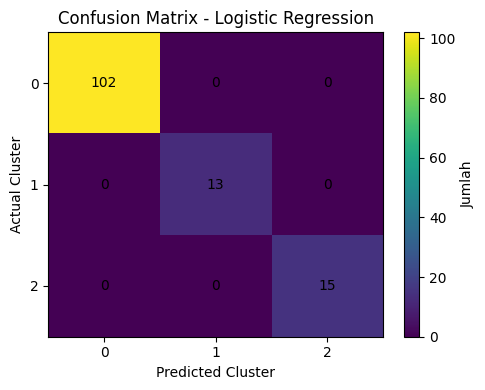

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        15

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



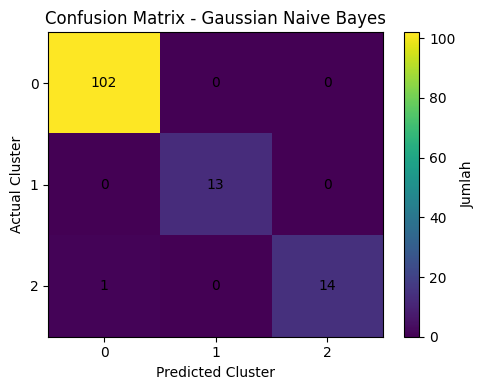

Classification Report - Gaussian Naive Bayes
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       102
           1       1.00      1.00      1.00        13
           2       1.00      0.93      0.97        15

    accuracy                           0.99       130
   macro avg       1.00      0.98      0.99       130
weighted avg       0.99      0.99      0.99       130



In [79]:
classification_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Gaussian Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ])
}

classification_results = []
classification_reports = {}
confusion_matrices = {}

for model_name, model in classification_models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    gap = train_accuracy - test_accuracy

    if gap > 0.10:
        fit_status = 'Indikasi overfitting'
    elif train_accuracy < 0.70 and test_accuracy < 0.70:
        fit_status = 'Indikasi underfitting'
    else:
        fit_status = 'Model stabil'

    classification_results.append({
        'model': model_name,
        'train_accuracy': round(train_accuracy, 4),
        'test_accuracy': round(test_accuracy, 4),
        'gap_train_test': round(gap, 4),
        'precision_weighted': round(precision_score(y_test, y_test_pred, average='weighted', zero_division=0), 4),
        'recall_weighted': round(recall_score(y_test, y_test_pred, average='weighted', zero_division=0), 4),
        'f1_weighted': round(f1_score(y_test, y_test_pred, average='weighted', zero_division=0), 4),
        'fit_status': fit_status
    })

    classification_reports[model_name] = classification_report(y_test, y_test_pred, zero_division=0)
    confusion_matrices[model_name] = confusion_matrix(y_test, y_test_pred)

classification_summary = pd.DataFrame(classification_results)
display(classification_summary)

for model_name, cm in confusion_matrices.items():
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, aspect='auto')
    plt.colorbar(label='Jumlah')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Cluster')
    plt.ylabel('Actual Cluster')
    plt.xticks(range(cm.shape[1]))
    plt.yticks(range(cm.shape[0]))

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center')

    plt.tight_layout()
    plt.show()

    print(f"Classification Report - {model_name}")
    print(classification_reports[model_name])

**Sumber Output:**  
Output berasal dari `accuracy_score()`, `precision_score()`, `recall_score()`, `f1_score()`, `confusion_matrix()`, dan `classification_report()` yang dihitung pada data training dan testing untuk kedua model.

**Interpretasi Output:**

| Model | Train Accuracy | Test Accuracy | Gap | Status |
|-------|---------------|---------------|-----|--------|
| Logistic Regression | **1,0000** | **1,0000** | 0,0000 | Model stabil |
| Gaussian Naive Bayes | **0,9904** | **0,9923** | −0,0019 | Model stabil |

Kedua model menghasilkan akurasi yang sangat tinggi dan gap antara train-test yang sangat kecil, menunjukkan tidak ada indikasi overfitting. Logistic Regression berhasil mengklasifikasikan seluruh data testing dengan benar, sementara Gaussian Naive Bayes memiliki satu kesalahan prediksi.

**Penjelasan Visualisasi (Confusion Matrix):**  
- Matriks berukuran 3×3 (sesuai jumlah cluster).
- **Diagonal utama** (dari kiri atas ke kanan bawah) menunjukkan jumlah prediksi yang **benar** — data yang diklasifikasikan ke cluster yang sesuai dengan label aktual.
- **Sel di luar diagonal** menunjukkan jumlah prediksi yang **salah** — data yang diklasifikasikan ke cluster yang tidak sesuai.
- Logistic Regression menghasilkan confusion matrix yang sempurna (seluruh nilai berada di diagonal).
- Gaussian Naive Bayes memiliki satu data pada cluster 2 yang diprediksi sebagai cluster 0.

**Catatan Interpretasi:**  
Akurasi 100% pada Logistic Regression bukan merupakan hal yang mencurigakan dalam konteks ini, karena target classification berasal dari label K-Means yang dibentuk dari fitur yang sama. Artinya, pola pemisahan cluster sangat jelas dan dapat dipelajari secara sempurna oleh model linear. Namun, **akurasi ini tidak boleh ditafsirkan sebagai kemampuan memprediksi risiko belajar aktual siswa**, karena label target bukan berasal dari data empiris risiko belajar, melainkan dari hasil clustering.

## 11. Regression

**Pengertian Linear Regression:**  
Linear Regression adalah metode *supervised learning* untuk memprediksi variabel kontinu (numerik). Model ini bekerja dengan mencari hubungan linear antara variabel independen (fitur) dan variabel dependen (target), menghasilkan persamaan garis yang meminimalkan jumlah kuadrat error.

**Alasan Regression Ditambahkan:**  
Regression ditambahkan sebagai komponen analisis tambahan agar notebook memenuhi kelengkapan tugas besar. Karena variabel `G1`, `G2`, dan `G3` tidak digunakan, target regression dipilih dari variabel non-nilai akademik, yaitu `absences_capped`.

**Catatan Metodologis:**  
Regression pada `absences_capped` **tidak menjadi dasar utama rekomendasi**. Rekomendasi utama tetap berasal dari profil cluster hasil K-Means. Jika R² regression rendah, artinya variabel yang digunakan belum mampu menjelaskan variasi ketidakhadiran siswa secara kuat, dan hasil regression perlu ditafsirkan dengan hati-hati.

### 11.1 Menentukan Target dan Feature Regression

**Tujuan Cell:**  
Cell ini bertujuan untuk menetapkan target dan fitur yang digunakan dalam model regression.

**Alasan Tahap Ini Diperlukan:**  
Target dan fitur perlu ditetapkan secara eksplisit untuk memastikan tidak terjadi data leakage (target masuk sebagai fitur) dan untuk mendokumentasikan pilihan yang diambil.

**Penjelasan Kode:**  
- Target: `absences_capped` — dipilih karena bersifat numerik kontinu, bukan nilai akademik, dan relevan dengan kedisiplinan belajar.
- Fitur: `studytime`, `failures`, `higher_num`, `schoolsup_num` — variabel yang berkaitan dengan intensitas belajar, risiko akademik, motivasi, dan dukungan sekolah.
- `absences_capped` tidak dimasukkan sebagai fitur untuk menghindari data leakage.

In [80]:
regression_target = 'absences_capped'
regression_features = ['studytime', 'failures', 'higher_num', 'schoolsup_num']

X_regression = df_model[regression_features].copy()
y_regression = df_model[regression_target].copy()

regression_setup = pd.DataFrame({
    'komponen': ['Target Regression', 'Feature Regression'],
    'isi': [regression_target, ', '.join(regression_features)],
    'alasan': [
        'Dipilih karena numerik, bukan nilai akademik, dan relevan dengan kedisiplinan belajar.',
        'Dipilih karena berkaitan dengan intensitas belajar, risiko akademik, motivasi, dan dukungan sekolah.'
    ]
})

display(regression_setup)

,komponen,isi,alasan
0,Target Regression,absences_capped,"Dipilih karena numerik, bukan nilai akademik, ..."
1,Feature Regression,"studytime, failures, higher_num, schoolsup_num",Dipilih karena berkaitan dengan intensitas bel...


**Sumber Output:**  
Output berasal dari tabel `regression_setup` yang menjelaskan target dan fitur regression beserta alasan pemilihannya.

**Interpretasi Output:**  
Tabel mengonfirmasi bahwa target regression adalah `absences_capped` dan fitur yang digunakan adalah `studytime`, `failures`, `higher_num`, dan `schoolsup_num`. Target tidak menggunakan nilai akademik, sehingga tetap konsisten dengan keputusan untuk tidak menggunakan G1, G2, dan G3 dalam seluruh proses analisis.

### 11.2 Training dan Evaluasi Regression

**Tujuan Cell:**  
Cell ini bertujuan untuk melatih model Linear Regression dan mengevaluasi kemampuannya dalam memprediksi `absences_capped`.

**Alasan Tahap Ini Diperlukan:**  
Evaluasi regression dilakukan menggunakan beberapa metrik untuk melihat seberapa baik model dapat menjelaskan variasi ketidakhadiran siswa berdasarkan empat fitur yang tersedia.

**Penjelasan Kode:**  
- Data dibagi menjadi 80% training dan 20% testing.
- `Pipeline([StandardScaler(), LinearRegression()])` melakukan standardisasi dan regression secara berurutan.
- Metrik evaluasi: R² (koefisien determinasi), MAE (Mean Absolute Error), MSE (Mean Squared Error), dan RMSE (Root Mean Squared Error).

In [81]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.2,
    random_state=42
)

regression_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

regression_model.fit(X_train_reg, y_train_reg)

y_train_reg_pred = regression_model.predict(X_train_reg)
y_test_reg_pred = regression_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_test_reg_pred)
mse = mean_squared_error(y_test_reg, y_test_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_test_reg_pred)
train_r2 = r2_score(y_train_reg, y_train_reg_pred)

regression_metrics = pd.DataFrame({
    'metrik': ['Train R2', 'Test R2', 'MAE', 'MSE', 'RMSE'],
    'nilai': [train_r2, r2, mae, mse, rmse],
    'interpretasi': [
        'Kemampuan model menjelaskan data training.',
        'Kemampuan model menjelaskan data testing.',
        'Rata-rata selisih absolut antara nilai aktual dan prediksi.',
        'Rata-rata kuadrat error prediksi.',
        'Akar dari MSE, lebih mudah dibaca karena satuannya sama dengan target.'
    ]
})

display(regression_metrics)

,metrik,nilai,interpretasi
0,Train R2,0.028346,Kemampuan model menjelaskan data training.
1,Test R2,0.058114,Kemampuan model menjelaskan data testing.
2,MAE,3.005673,Rata-rata selisih absolut antara nilai aktual ...
3,MSE,14.412307,Rata-rata kuadrat error prediksi.
4,RMSE,3.796354,"Akar dari MSE, lebih mudah dibaca karena satua..."


**Sumber Output:**  
Output berasal dari perhitungan `r2_score()`, `mean_absolute_error()`, dan `mean_squared_error()` pada data training dan testing.

**Interpretasi Output:**

| Metrik | Nilai | Interpretasi |
|--------|-------|-------------|
| Train R² | **0,0283** | Model hanya mampu menjelaskan sekitar 2,8% variasi data training. |
| Test R² | **0,0581** | Model hanya mampu menjelaskan sekitar 5,8% variasi data testing. |
| MAE | **3,0057** | Rata-rata selisih absolut antara nilai aktual dan prediksi adalah sekitar 3 poin. |
| MSE | **14,4123** | Rata-rata kuadrat error prediksi. |
| RMSE | **3,7964** | Akar MSE, lebih mudah dibaca karena satuannya sama dengan target. |

R² yang rendah menunjukkan bahwa keempat fitur (`studytime`, `failures`, `higher_num`, `schoolsup_num`) belum mampu menjelaskan variasi ketidakhadiran siswa secara kuat. Hal ini wajar karena ketidakhadiran dapat dipengaruhi oleh banyak faktor lain yang tidak tersedia dalam dataset, seperti kondisi kesehatan, jarak tempuh, faktor keluarga, atau faktor sosial.

**Catatan Interpretasi:**  
R² rendah bukan berarti analisis gagal. Ini menunjukkan **keterbatasan fitur yang tersedia** dalam menjelaskan variabel target. Regression pada notebook ini berfungsi sebagai analisis tambahan dan tidak dijadikan dasar utama rekomendasi. Rekomendasi utama tetap berasal dari profil cluster K-Means.

## 12. Scatter Plot Actual vs Predicted

**Tujuan Cell:**  
Cell ini bertujuan untuk memvisualisasikan perbandingan antara nilai `absences_capped` aktual dan nilai prediksi dari model regression.

**Alasan Tahap Ini Diperlukan:**  
Scatter plot actual vs predicted memberikan gambaran visual tentang seberapa dekat prediksi model dengan nilai sebenarnya. Grafik ini melengkapi evaluasi numerik (R², MAE, RMSE) dengan representasi visual.

**Penjelasan Kode:**  
- `plt.scatter()` menampilkan titik-titik perbandingan antara nilai aktual (sumbu X) dan prediksi (sumbu Y).
- Garis diagonal putus-putus menunjukkan kondisi ideal di mana prediksi = aktual.

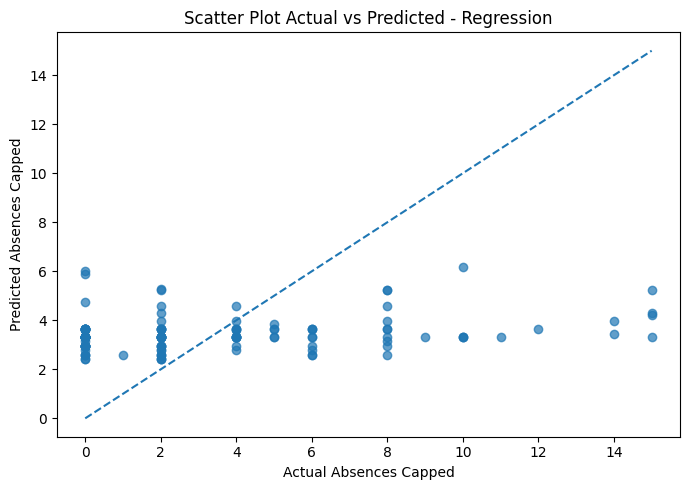

In [82]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_test_reg_pred, alpha=0.7)

min_value = min(y_test_reg.min(), y_test_reg_pred.min())
max_value = max(y_test_reg.max(), y_test_reg_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')

plt.title('Scatter Plot Actual vs Predicted - Regression')
plt.xlabel('Actual Absences Capped')
plt.ylabel('Predicted Absences Capped')
plt.tight_layout()
plt.show()

**Sumber Output:**  
Output berupa scatter plot yang membandingkan nilai aktual `absences_capped` pada data testing dengan nilai prediksi dari model regression.

**Penjelasan Visualisasi (Scatter Plot Actual vs Predicted):**  
- Sumbu X menunjukkan nilai aktual `absences_capped`, sumbu Y menunjukkan nilai prediksi model.
- **Garis diagonal putus-putus** menunjukkan kondisi prediksi ideal (predicted = actual). Semakin dekat titik-titik data ke garis ini, semakin baik prediksi model.
- Jika titik-titik menyebar jauh dari garis diagonal, maka kemampuan model masih terbatas.

**Interpretasi Output:**  
Berdasarkan R² yang rendah (sekitar 0,058), titik-titik data tidak mengikuti garis diagonal secara rapat. Sebaran titik menunjukkan bahwa prediksi model cenderung berkumpul di sekitar nilai rata-rata, sementara nilai aktual yang tinggi atau rendah tidak terprediksi dengan baik.

**Catatan Interpretasi:**  
Scatter plot ini mengonfirmasi secara visual bahwa regression pada `absences_capped` memiliki keterbatasan. Hasil ini konsisten dengan R² rendah yang sudah dibahas pada bagian sebelumnya. Rekomendasi utama tetap berasal dari hasil clustering dan profil cluster, bukan dari model regression.

## 13. Model Saving dengan Pickle

**Tujuan Cell:**  
Cell ini bertujuan untuk menyimpan seluruh model, scaler, profil cluster, metrik evaluasi, dan artefak pendukung lainnya ke dalam file agar dapat digunakan kembali tanpa perlu melatih ulang model.

**Alasan Tahap Ini Diperlukan:**  
Model saving memungkinkan hasil analisis digunakan kembali pada dashboard Streamlit atau aplikasi lain tanpa harus menjalankan ulang seluruh notebook. File yang disimpan mencakup:

- `student_segment_result_final.csv` — Dataframe hasil lengkap dengan label cluster.
- `cluster_profile_final.csv` — Profil rata-rata setiap cluster.
- `student_segment_model_bundle_final.pkl` — Bundle model lengkap.

**Isi Model Bundle:**

| Key | Isi | Kegunaan di Dashboard |
|-----|-----|----------------------|
| `selected_features` | Daftar 5 fitur final | Input prediksi |
| `scaler_kmeans` | StandardScaler | Transformasi input baru |
| `kmeans_model` | Model K-Means (k=3) | Prediksi cluster |
| `classification_models` | LR & GNB Pipeline | Uji konsistensi cluster |
| `regression_model` | Linear Regression Pipeline | Analisis tambahan |
| `cluster_names` | Nama cluster (0, 1, 2) | Label interpretasi |
| `cluster_recommendations` | Rekomendasi per cluster | Halaman Rekomendasi |
| `cluster_profile` | Profil rata-rata fitur | Halaman Profil |
| `clustering_metrics` | Silhouette, DBI, Inertia | Halaman Evaluasi |
| `classification_summary` | Akurasi, precision, recall, F1 | Halaman Evaluasi |
| `regression_metrics` | R², MAE, MSE, RMSE | Halaman Evaluasi |
| `absences_capping_bounds` | Batas IQR (lower, upper) | Batas input absences |
| `cluster_eval` | Evaluasi k=2 s/d k=5 | Grafik Elbow, Silhouette, DBI |
| `candidate_evaluation` | Evaluasi kandidat fitur | Referensi |
| `pca_df` | PC1, PC2, cluster | Scatter plot PCA |
| `pca_explained_variance` | Explained variance ratio | Metrik PCA |
| `confusion_matrices` | CM per model classification | Heatmap CM |
| `regression_actual_pred` | Actual vs predicted absences | Scatter plot regression |

**Penjelasan Kode:**  
- `pickle.dump()` menyimpan objek Python ke dalam file biner `.pkl`.
- `regression_actual_pred` dibuat dari `y_test_reg` dan `y_test_reg_pred` untuk keperluan scatter plot di dashboard.
- Model bundle berisi seluruh komponen yang dibutuhkan dashboard.

In [83]:
# Simpan dataframe hasil
df_result = df_model.copy()
df_result['cluster_name'] = df_result['cluster'].map(cluster_names)
df_result['cluster_recommendation'] = df_result['cluster'].map(cluster_recommendations)

df_result.to_csv('student_segment_result_final.csv', index=False)
cluster_profile.to_csv('cluster_profile_final.csv')
candidate_evaluation.to_csv('candidate_feature_evaluation.csv', index=False)
cluster_eval.to_csv('cluster_k_evaluation.csv', index=False)
classification_summary.to_csv('classification_summary.csv', index=False)
regression_metrics.to_csv('regression_metrics.csv', index=False)

# Buat regression_actual_pred untuk scatter plot di dashboard
regression_actual_pred = pd.DataFrame({
    "actual_absences_capped": y_test_reg.values,
    "predicted_absences_capped": y_test_reg_pred
})

model_bundle = {
    'selected_features': selected_features,
    'regression_features': regression_features,
    'regression_target': regression_target,
    'scaler_kmeans': scaler_kmeans,
    'kmeans_model': kmeans_final,
    'classification_models': classification_models,
    'regression_model': regression_model,
    'cluster_names': cluster_names,
    'cluster_recommendations': cluster_recommendations,
    'cluster_profile': cluster_profile,
    'clustering_metrics': {
        'silhouette_score': float(final_silhouette),
        'davies_bouldin_index': float(final_dbi),
        'inertia': float(final_inertia)
    },
    'classification_summary': classification_summary,
    'regression_metrics': regression_metrics,
    'absences_capping_bounds': {
        'lower_bound': float(lower_abs),
        'upper_bound': float(upper_abs)
    },
    'cluster_eval': cluster_eval,
    'candidate_evaluation': candidate_evaluation,
    'pca_df': pca_df,
    'pca_explained_variance': explained_variance,
    'confusion_matrices': confusion_matrices,
    'regression_actual_pred': regression_actual_pred
}

with open('student_segment_model_bundle_final.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("File hasil dan model berhasil disimpan.")
print("student_segment_result_final.csv")
print("cluster_profile_final.csv")
print("student_segment_model_bundle_final.pkl")

File hasil dan model berhasil disimpan.
student_segment_result_final.csv
cluster_profile_final.csv
student_segment_model_bundle_final.pkl


**Sumber Output:**  
Output berasal dari perintah `print()` yang mengonfirmasi bahwa file berhasil disimpan.

**Interpretasi Output:**  
Pesan `File hasil dan model berhasil disimpan` mengonfirmasi bahwa seluruh artefak sudah tersedia. File `.pkl` kini berisi 20 item (termasuk 6 item tambahan: `cluster_eval`, `candidate_evaluation`, `pca_df`, `pca_explained_variance`, `confusion_matrices`, dan `regression_actual_pred`) yang dibutuhkan dashboard Streamlit.

## 14. Membuat File `app.py` untuk Dashboard Streamlit

**Tujuan Cell:**  
Cell ini bertujuan untuk menghasilkan file `app.py` dan `requirements.txt` yang digunakan untuk menjalankan dashboard Streamlit.

**Alasan Tahap Ini Diperlukan:**  
Dashboard memberikan antarmuka interaktif bagi pengguna untuk mengeksplorasi hasil analisis data mining.

**Struktur Menu Dashboard (6 halaman):**

| Menu | Fungsi |
|------|--------|
| **Ringkasan Dashboard** | Penjelasan umum project, model, fitur, dan batasan interpretasi |
| **Prediksi Siswa** | Input karakteristik siswa → prediksi cluster K-Means + pembanding classification |
| **Profil Cluster** | Tabel profil, bar chart distribusi, dan interpretasi per cluster |
| **Visualisasi Cluster** | Scatter plot PCA dengan explained variance |
| **Evaluasi Model** | Evaluasi clustering (3 grafik + tabel k=2-5), classification (confusion matrix), regression (scatter plot) |
| **Rekomendasi** | Tabel rekomendasi dan penjelasan per cluster |

**Penjelasan Kode:**  
- File `app.py` memuat model dari `student_segment_model_bundle_final.pkl` dan menggunakan seluruh 20 item bundle.
- Input `absences_capped` dibatasi sesuai batas capping IQR (`bundle["absences_capping_bounds"]["upper_bound"]`).
- Setiap halaman dilengkapi penjelasan kontekstual, cara membaca grafik, dan catatan batasan interpretasi.
- File `requirements.txt` mencantumkan library yang dibutuhkan untuk menjalankan dashboard.

In [84]:
app_code = r"""
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt

APP_TITLE = "Dashboard Segmentasi Risiko Belajar Siswa"
BUNDLE_PATH = Path("student_segment_model_bundle_final.pkl")

st.set_page_config(page_title=APP_TITLE, page_icon="\U0001f393", layout="wide")


@st.cache_resource
def load_bundle():
    if not BUNDLE_PATH.exists():
        st.error("File student_segment_model_bundle_final.pkl tidak ditemukan.")
        st.stop()
    with open(BUNDLE_PATH, "rb") as f:
        return pickle.load(f)


bundle = load_bundle()

selected_features = bundle["selected_features"]
scaler_kmeans = bundle["scaler_kmeans"]
kmeans_model = bundle["kmeans_model"]
classification_models = bundle["classification_models"]
regression_model = bundle["regression_model"]
cluster_names = bundle["cluster_names"]
cluster_recommendations = bundle["cluster_recommendations"]
cluster_profile = bundle["cluster_profile"]
classification_summary = bundle["classification_summary"]
regression_metrics_df = bundle["regression_metrics"]
clustering_metrics = bundle["clustering_metrics"]

st.title(APP_TITLE)
st.caption(
    "Model utama: K-Means (3 cluster) "
    "| Supervised: Logistic Regression & Gaussian Naive Bayes "
    "| Regression: Linear Regression"
)

menu = st.sidebar.radio(
    "Menu",
    [
        "Ringkasan Dashboard",
        "Prediksi Siswa",
        "Profil Cluster",
        "Visualisasi Cluster",
        "Evaluasi Model",
        "Rekomendasi",
    ],
)

# ================================================================
# 1. RINGKASAN DASHBOARD
# ================================================================
if menu == "Ringkasan Dashboard":
    st.header("Ringkasan Dashboard")

    st.markdown(
        "Dashboard ini merupakan antarmuka interaktif untuk "
        "**Segmentasi Risiko Belajar dan Dukungan Akademik Siswa** "
        "menggunakan dataset `student-por.csv`. Tujuan utama dashboard "
        "adalah menampilkan hasil segmentasi siswa ke dalam tiga kelompok "
        "berdasarkan karakteristik risiko belajar, motivasi pendidikan, "
        "dan dukungan akademik."
    )

    st.subheader("Model yang Digunakan")
    st.markdown(
        '''
| Model | Peran |
|-------|-------|
| **K-Means** (model utama) | Membentuk segmentasi siswa ke dalam 3 cluster berdasarkan kemiripan karakteristik. |
| **Logistic Regression** | Menguji apakah pola cluster K-Means dapat dipelajari oleh model supervised. |
| **Gaussian Naive Bayes** | Pembanding Logistic Regression untuk menguji konsistensi pola cluster. |
| **Linear Regression** | Analisis tambahan untuk memprediksi ketidakhadiran siswa (`absences_capped`). |
'''
    )

    st.subheader("Fitur yang Digunakan")
    feature_table = pd.DataFrame(
        {
            "Variabel": [
                "studytime",
                "failures",
                "absences_capped",
                "higher_num",
                "schoolsup_num",
            ],
            "Makna": [
                "Waktu belajar mingguan siswa.",
                "Riwayat kegagalan akademik sebelumnya.",
                "Jumlah ketidakhadiran setelah capping outlier.",
                "Motivasi melanjutkan pendidikan tinggi.",
                "Dukungan tambahan dari sekolah.",
            ],
        }
    )
    st.dataframe(feature_table, use_container_width=True, hide_index=True)

    st.subheader("Catatan Penting")
    st.warning(
        "**Variabel G1, G2, dan G3 (nilai akademik) tidak digunakan** "
        "dalam seluruh proses analisis, model, dashboard, maupun rekomendasi. "
        "Hasil dashboard tidak boleh dimaknai sebagai prediksi nilai akademik "
        "atau prestasi belajar siswa."
    )
    st.info(
        "Classification hanya menguji konsistensi label cluster, bukan "
        "memprediksi risiko belajar aktual. Regression hanya analisis tambahan. "
        "Rekomendasi utama berasal dari profil cluster K-Means."
    )

# ================================================================
# 2. PREDIKSI SISWA
# ================================================================
elif menu == "Prediksi Siswa":
    st.header("Prediksi Segmentasi Siswa")

    st.markdown(
        "Masukkan karakteristik siswa pada form berikut. Data input akan "
        "diproses menggunakan `StandardScaler` yang sama dengan proses training, "
        "lalu dimasukkan ke model K-Means untuk menentukan cluster segmentasi."
    )

    abs_upper = float(
        bundle.get("absences_capping_bounds", {}).get("upper_bound", 15.0)
    )

    col1, col2 = st.columns(2)

    with col1:
        studytime = st.selectbox(
            "Studytime / waktu belajar mingguan",
            [1, 2, 3, 4],
            format_func=lambda x: {
                1: "1 \u2014 kurang dari 2 jam/minggu",
                2: "2 \u2014 antara 2 sampai 5 jam/minggu",
                3: "3 \u2014 antara 5 sampai 10 jam/minggu",
                4: "4 \u2014 lebih dari 10 jam/minggu",
            }[x],
        )
        failures = st.selectbox(
            "Failures / kegagalan akademik sebelumnya",
            [0, 1, 2, 3],
            format_func=lambda x: (
                "0 \u2014 Tidak pernah gagal" if x == 0 else f"{x} kali"
            ),
        )
        absences_capped = st.number_input(
            "Absences capped / jumlah ketidakhadiran",
            min_value=0.0,
            max_value=abs_upper,
            value=4.0,
            step=1.0,
        )
        st.caption(
            f"Nilai absensi dibatasi 0\u2013{int(abs_upper)} berdasarkan "
            "hasil capping outlier metode IQR."
        )

    with col2:
        higher_num = st.radio(
            "Ingin melanjutkan pendidikan tinggi?",
            [1, 0],
            format_func=lambda x: "Ya" if x == 1 else "Tidak",
        )
        schoolsup_num = st.radio(
            "Mendapat dukungan tambahan dari sekolah?",
            [1, 0],
            format_func=lambda x: "Ya" if x == 1 else "Tidak",
        )

    input_df = pd.DataFrame(
        [
            {
                "studytime": studytime,
                "failures": failures,
                "absences_capped": absences_capped,
                "higher_num": higher_num,
                "schoolsup_num": schoolsup_num,
            }
        ]
    )

    if st.button("Prediksi Cluster", use_container_width=True):
        X_input_scaled = scaler_kmeans.transform(input_df[selected_features])
        cluster_result = int(kmeans_model.predict(X_input_scaled)[0])

        st.subheader(
            f"Hasil: Cluster {cluster_result} \u2014 "
            f"{cluster_names.get(cluster_result, 'Tidak dikenal')}"
        )
        st.info(
            cluster_recommendations.get(cluster_result, "Rekomendasi belum tersedia.")
        )

        st.markdown("**Data input siswa:**")
        st.dataframe(input_df, use_container_width=True, hide_index=True)

        st.markdown("**Prediksi supervised learning terhadap cluster:**")
        pred_rows = []
        for model_name, model in classification_models.items():
            pred_cluster = int(model.predict(input_df)[0])
            pred_rows.append(
                {
                    "Model": model_name,
                    "Predicted Cluster": pred_cluster,
                    "Nama Cluster": cluster_names.get(pred_cluster, ""),
                }
            )
        st.dataframe(
            pd.DataFrame(pred_rows), use_container_width=True, hide_index=True
        )

        st.caption(
            "Catatan: Prediksi supervised learning hanya menguji konsistensi "
            "pola cluster K-Means, bukan memprediksi nilai akademik siswa."
        )

# ================================================================
# 3. PROFIL CLUSTER
# ================================================================
elif menu == "Profil Cluster":
    st.header("Profil Cluster")

    st.markdown(
        "Profil cluster dihitung dari **rata-rata setiap fitur** pada "
        "masing-masing cluster hasil K-Means. Interpretasi cluster didasarkan "
        "pada karakteristik dominan yang terlihat dari data, bukan dari "
        "asumsi yang dibuat sebelum analisis."
    )

    st.subheader("Tabel Profil Cluster")
    st.dataframe(cluster_profile, use_container_width=True)

    st.subheader("Distribusi Jumlah Siswa per Cluster")
    if "jumlah_siswa" in cluster_profile.columns:
        fig, ax = plt.subplots(figsize=(7, 4))
        counts = cluster_profile["jumlah_siswa"]
        colors_bar = ["#2ecc71", "#3498db", "#e74c3c"]
        bars = ax.bar(
            range(len(counts)),
            counts.values,
            color=colors_bar[: len(counts)],
        )
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels([f"Cluster {i}" for i in counts.index])
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Jumlah Siswa")
        ax.set_title("Distribusi Jumlah Siswa per Cluster")
        for bar_item, val in zip(bars, counts.values):
            ax.text(
                bar_item.get_x() + bar_item.get_width() / 2.0,
                bar_item.get_height() + 5,
                str(int(val)),
                ha="center",
                va="bottom",
                fontweight="bold",
            )
        plt.tight_layout()
        st.pyplot(fig)

    st.subheader("Interpretasi Cluster")
    for cid, cname in cluster_names.items():
        st.markdown(f"**Cluster {cid} \u2014 {cname}**")
        rec = cluster_recommendations.get(cid, "")
        st.markdown(f"> {rec}")

    st.caption(
        "Catatan: Interpretasi cluster tidak menggunakan variabel G1, G2, "
        "atau G3. Nama cluster bersifat deskriptif berdasarkan rata-rata "
        "fitur yang teramati."
    )

# ================================================================
# 4. VISUALISASI CLUSTER
# ================================================================
elif menu == "Visualisasi Cluster":
    st.header("Visualisasi Cluster (PCA)")

    st.markdown(
        "PCA (Principal Component Analysis) digunakan untuk mereduksi lima "
        "fitur menjadi dua komponen utama agar hasil clustering dapat "
        "divisualisasikan dalam scatter plot dua dimensi."
    )

    pca_df = bundle.get("pca_df", None)
    pca_var = bundle.get("pca_explained_variance", None)

    if pca_df is not None:
        if isinstance(pca_df, dict):
            pca_df = pd.DataFrame(pca_df)

        if pca_var is not None:
            pca_var_arr = np.array(pca_var)
            pc1_var = round(float(pca_var_arr[0]) * 100, 2)
            pc2_var = round(float(pca_var_arr[1]) * 100, 2)
            total_var = round(pc1_var + pc2_var, 2)

            vc1, vc2, vc3 = st.columns(3)
            vc1.metric("PC1 Explained Variance", f"{pc1_var}%")
            vc2.metric("PC2 Explained Variance", f"{pc2_var}%")
            vc3.metric("Total Explained Variance", f"{total_var}%")

        fig, ax = plt.subplots(figsize=(8, 6))
        colors_pca = ["#2ecc71", "#3498db", "#e74c3c"]
        for cluster_id in sorted(pca_df["cluster"].unique()):
            mask = pca_df["cluster"] == cluster_id
            label = f"Cluster {cluster_id}: {cluster_names.get(cluster_id, '')}"
            ax.scatter(
                pca_df.loc[mask, "PC1"],
                pca_df.loc[mask, "PC2"],
                s=60,
                alpha=0.7,
                label=label,
                color=colors_pca[int(cluster_id) % len(colors_pca)],
            )
        ax.set_xlabel("Principal Component 1")
        ax.set_ylabel("Principal Component 2")
        ax.set_title("Visualisasi Cluster K-Means Menggunakan PCA")
        ax.legend(title="Cluster", loc="best")
        plt.tight_layout()
        st.pyplot(fig)

        st.info(
            "**Cara membaca grafik PCA:** Setiap titik mewakili satu siswa. "
            "Warna menunjukkan cluster yang ditetapkan K-Means. "
            "Jika cluster terlihat terpisah, pola segmentasi cukup jelas. "
            "Tumpang tindih di beberapa area wajar karena PCA hanya "
            "menampilkan sebagian variasi data."
        )

        st.caption(
            "Catatan: PCA hanya alat bantu visualisasi dua dimensi, bukan "
            "dasar tunggal penentuan kualitas cluster. Keputusan cluster "
            "tetap didasarkan pada metrik evaluasi dan profil cluster."
        )
    else:
        st.warning(
            "Data PCA belum tersedia di model bundle. Jalankan ulang notebook "
            "dan simpan pca_df ke dalam bundle."
        )

# ================================================================
# 5. EVALUASI MODEL
# ================================================================
elif menu == "Evaluasi Model":
    st.header("Evaluasi Model")

    eval_tab = st.radio(
        "Pilih evaluasi:",
        [
            "Evaluasi Clustering K-Means",
            "Evaluasi Classification",
            "Evaluasi Regression",
        ],
        horizontal=True,
    )

    # --- A. EVALUASI CLUSTERING ---
    if eval_tab == "Evaluasi Clustering K-Means":
        st.subheader("Evaluasi Clustering K-Means")

        st.markdown(
            "Evaluasi clustering menggunakan tiga metrik utama untuk menilai "
            "kualitas segmentasi yang dihasilkan K-Means."
        )

        mc1, mc2, mc3 = st.columns(3)
        mc1.metric(
            "Silhouette Score",
            f"{clustering_metrics.get('silhouette_score', 0):.4f}",
        )
        mc2.metric(
            "Davies-Bouldin Index",
            f"{clustering_metrics.get('davies_bouldin_index', 0):.4f}",
        )
        mc3.metric(
            "Inertia",
            f"{clustering_metrics.get('inertia', 0):.2f}",
        )

        st.markdown(
            '''
| Metrik | Interpretasi |
|--------|-------------|
| **Silhouette Score** | Mengukur kekompakan dan pemisahan cluster. Rentang -1 sampai 1, semakin tinggi semakin baik. |
| **Davies-Bouldin Index** | Mengukur kualitas pemisahan antarcluster. Semakin kecil semakin baik. |
| **Inertia** | Total jarak data terhadap centroid. Tidak boleh dipakai sendirian untuk memilih k. |
'''
        )

        cluster_eval_data = bundle.get("cluster_eval", None)
        if cluster_eval_data is not None:
            if isinstance(cluster_eval_data, dict):
                cluster_eval_data = pd.DataFrame(cluster_eval_data)

            st.subheader("Perbandingan k = 2 sampai k = 5")
            display_cols = [c for c in cluster_eval_data.columns if c != "distribusi_cluster"]
            st.dataframe(
                cluster_eval_data[display_cols] if len(display_cols) < len(cluster_eval_data.columns) else cluster_eval_data,
                use_container_width=True,
                hide_index=True,
            )

            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            k_vals = cluster_eval_data["k"].values

            axes[0].plot(k_vals, cluster_eval_data["inertia"].values, marker="o", color="#2c3e50")
            axes[0].set_title("Elbow Method (Inertia)")
            axes[0].set_xlabel("Jumlah Cluster (k)")
            axes[0].set_ylabel("Inertia")
            axes[0].set_xticks(k_vals)

            axes[1].plot(k_vals, cluster_eval_data["silhouette_score"].values, marker="o", color="#27ae60")
            axes[1].set_title("Silhouette Score per k")
            axes[1].set_xlabel("Jumlah Cluster (k)")
            axes[1].set_ylabel("Silhouette Score")
            axes[1].set_xticks(k_vals)

            axes[2].plot(k_vals, cluster_eval_data["davies_bouldin_index"].values, marker="o", color="#e74c3c")
            axes[2].set_title("Davies-Bouldin Index per k")
            axes[2].set_xlabel("Jumlah Cluster (k)")
            axes[2].set_ylabel("DBI")
            axes[2].set_xticks(k_vals)

            plt.tight_layout()
            st.pyplot(fig)

            st.caption(
                "Pemilihan k mempertimbangkan kombinasi ketiga metrik dan "
                "kemudahan interpretasi cluster, bukan satu metrik saja."
            )

    # --- B. EVALUASI CLASSIFICATION ---
    elif eval_tab == "Evaluasi Classification":
        st.subheader("Evaluasi Classification")

        st.markdown(
            "Classification digunakan untuk menguji apakah pola cluster "
            "K-Means dapat dipelajari oleh model supervised learning. "
            "Target classification berasal dari **label cluster K-Means**, "
            "bukan label asli dari dataset."
        )

        st.dataframe(
            classification_summary, use_container_width=True, hide_index=True
        )

        cm_data = bundle.get("confusion_matrices", None)
        if cm_data is not None:
            st.subheader("Confusion Matrix")
            cm_cols = st.columns(2)

            for idx, (model_name, cm) in enumerate(cm_data.items()):
                cm_array = np.array(cm)
                with cm_cols[idx % 2]:
                    fig, ax = plt.subplots(figsize=(5, 4))
                    im = ax.imshow(cm_array, cmap="Blues", aspect="auto")
                    plt.colorbar(im, ax=ax, label="Jumlah")
                    ax.set_title(f"Confusion Matrix\n{model_name}")
                    ax.set_xlabel("Predicted Cluster")
                    ax.set_ylabel("Actual Cluster")
                    ax.set_xticks(range(cm_array.shape[1]))
                    ax.set_yticks(range(cm_array.shape[0]))
                    for i in range(cm_array.shape[0]):
                        for j in range(cm_array.shape[1]):
                            text_color = (
                                "white"
                                if cm_array[i, j] > cm_array.max() / 2
                                else "black"
                            )
                            ax.text(
                                j, i, str(int(cm_array[i, j])),
                                ha="center", va="center", color=text_color,
                            )
                    plt.tight_layout()
                    st.pyplot(fig)

            st.markdown(
                "**Cara membaca confusion matrix:** Nilai pada **diagonal "
                "utama** menunjukkan jumlah prediksi yang benar. Nilai di "
                "**luar diagonal** menunjukkan jumlah prediksi yang salah."
            )

        st.warning(
            "Akurasi classification yang tinggi **tidak berarti** model "
            "mampu memprediksi risiko belajar aktual siswa. Target "
            "classification berasal dari label cluster hasil K-Means, "
            "sehingga akurasi hanya menunjukkan konsistensi pola cluster, "
            "bukan kemampuan prediksi terhadap data baru dengan label asli."
        )

    # --- C. EVALUASI REGRESSION ---
    elif eval_tab == "Evaluasi Regression":
        st.subheader("Evaluasi Regression")

        st.markdown(
            "Linear Regression digunakan sebagai analisis tambahan untuk "
            "memprediksi `absences_capped` menggunakan fitur `studytime`, "
            "`failures`, `higher_num`, dan `schoolsup_num`."
        )

        st.dataframe(
            regression_metrics_df, use_container_width=True, hide_index=True
        )

        reg_pred = bundle.get("regression_actual_pred", None)
        if reg_pred is not None:
            if isinstance(reg_pred, dict):
                reg_pred = pd.DataFrame(reg_pred)

            st.subheader("Scatter Plot Actual vs Predicted")
            fig, ax = plt.subplots(figsize=(7, 5))
            ax.scatter(
                reg_pred["actual_absences_capped"],
                reg_pred["predicted_absences_capped"],
                alpha=0.7,
                color="#3498db",
            )
            min_val = min(
                reg_pred["actual_absences_capped"].min(),
                reg_pred["predicted_absences_capped"].min(),
            )
            max_val = max(
                reg_pred["actual_absences_capped"].max(),
                reg_pred["predicted_absences_capped"].max(),
            )
            ax.plot(
                [min_val, max_val],
                [min_val, max_val],
                linestyle="--",
                color="#e74c3c",
                label="Prediksi ideal",
            )
            ax.set_title("Scatter Plot Actual vs Predicted \u2014 Regression")
            ax.set_xlabel("Actual Absences Capped")
            ax.set_ylabel("Predicted Absences Capped")
            ax.legend()
            plt.tight_layout()
            st.pyplot(fig)

            st.markdown(
                "**Cara membaca grafik:** Garis diagonal putus-putus "
                "menunjukkan kondisi prediksi ideal (predicted = actual). "
                "Semakin dekat titik-titik ke garis ini, semakin baik "
                "prediksi model. Jika titik menyebar jauh dari garis, "
                "kemampuan model masih terbatas."
            )

        st.warning(
            "Regression hanya analisis tambahan untuk memprediksi "
            "`absences_capped`. Jika R\u00b2 rendah, artinya fitur yang "
            "digunakan belum mampu menjelaskan variasi ketidakhadiran "
            "secara kuat. Rekomendasi utama tetap berdasarkan profil "
            "cluster K-Means, bukan hasil regression."
        )

# ================================================================
# 6. REKOMENDASI
# ================================================================
elif menu == "Rekomendasi":
    st.header("Rekomendasi per Cluster")

    st.markdown(
        "Rekomendasi berikut dibuat berdasarkan **profil rata-rata cluster** "
        "hasil K-Means. Setiap cluster memiliki karakteristik dominan yang "
        "berbeda, sehingga rekomendasi disesuaikan dengan kebutuhan "
        "masing-masing kelompok."
    )

    rec_data = []
    for cid, cname in cluster_names.items():
        rec_data.append(
            {
                "Cluster": cid,
                "Nama Cluster": cname,
                "Rekomendasi": cluster_recommendations.get(cid, ""),
            }
        )
    st.dataframe(
        pd.DataFrame(rec_data), use_container_width=True, hide_index=True
    )

    st.divider()

    for cid, cname in cluster_names.items():
        st.subheader(f"Cluster {cid}: {cname}")
        st.info(
            cluster_recommendations.get(cid, "Rekomendasi belum tersedia.")
        )

    st.caption(
        "Catatan: Rekomendasi tidak berdasarkan nilai G1, G2, dan G3. "
        "Hasil classification hanya menguji konsistensi pola cluster, "
        "bukan memprediksi nilai akademik asli siswa. "
        "Rekomendasi utama dibuat berdasarkan profil cluster K-Means."
    )

# Footer
st.divider()
st.caption(
    "Catatan: G1, G2, dan G3 tidak digunakan dalam model. "
    "Hasil classification hanya menguji konsistensi pola cluster, "
    "bukan memprediksi nilai akademik asli siswa. "
    "Rekomendasi utama dibuat berdasarkan profil cluster K-Means."
)
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

requirements_text = "\n".join([
    "streamlit",
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    ""
])

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_text)

print("File app.py dan requirements.txt berhasil dibuat.")

File app.py dan requirements.txt berhasil dibuat.


**Sumber Output:**  
Output berasal dari perintah `print()` yang mengonfirmasi bahwa file `app.py` dan `requirements.txt` berhasil dibuat.

**Interpretasi Output:**  
Kedua file berhasil dibuat dan siap digunakan. File `app.py` mengambil model dari `student_segment_model_bundle_final.pkl` dan menyediakan enam halaman: Ringkasan Dashboard, Prediksi Siswa, Profil Cluster, Visualisasi Cluster, Evaluasi Model, dan Rekomendasi.

## 15. Streamlit Deployment melalui Local, GitHub, atau Ngrok

**Tujuan Cell:**  
Cell ini bertujuan untuk membuat file ZIP yang berisi seluruh file yang diperlukan untuk deployment dashboard.

**Alasan Tahap Ini Diperlukan:**  
File ZIP memudahkan distribusi dan deployment. Pengguna dapat mengunduh ZIP, kemudian menjalankan dashboard secara lokal atau mengunggah ke platform seperti GitHub dan Streamlit Community Cloud.

In [85]:
deployment_files = [
    'app.py',
    'requirements.txt',
    'student_segment_model_bundle_final.pkl',
    'student_segment_result_final.csv',
    'cluster_profile_final.csv',
    'candidate_feature_evaluation.csv',
    'cluster_k_evaluation.csv',
    'classification_summary.csv',
    'regression_metrics.csv'
]

zip_name = 'student_learning_segment_COMPLETE_COLAB_project.zip'

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in deployment_files:
        if os.path.exists(file):
            zipf.write(file)

print("ZIP deployment berhasil dibuat:", zip_name)
print("File yang disertakan:")
for file in deployment_files:
    if os.path.exists(file):
        print("-", file)

ZIP deployment berhasil dibuat: student_learning_segment_COMPLETE_COLAB_project.zip
File yang disertakan:
- app.py
- requirements.txt
- student_segment_model_bundle_final.pkl
- student_segment_result_final.csv
- cluster_profile_final.csv
- candidate_feature_evaluation.csv
- cluster_k_evaluation.csv
- classification_summary.csv
- regression_metrics.csv


**Sumber Output:**  
Output berasal dari proses pembuatan file ZIP dan daftar file yang disertakan.

**Interpretasi Output:**  
ZIP berisi seluruh file yang diperlukan untuk menjalankan dashboard:

- `app.py` — Kode dashboard Streamlit.
- `requirements.txt` — Daftar library yang diperlukan.
- `student_segment_model_bundle_final.pkl` — Bundle model.
- File CSV hasil evaluasi dan profil.

**Cara Menjalankan Dashboard Secara Lokal:**

```bash
pip install -r requirements.txt
streamlit run app.py
```

Untuk deployment permanen, unggah seluruh file ke GitHub lalu hubungkan repositori ke Streamlit Community Cloud.

## 16. Ringkasan Akhir dan Rekomendasi

### Rangkuman Proses

Notebook ini telah menyelesaikan seluruh tahapan data mining, meliputi:

1. **Data Understanding** — Pemeriksaan struktur data, missing value, duplikasi, statistik deskriptif, korelasi, dan distribusi.
2. **Data Preparation** — Handling missing value dan duplikasi, encoding kategorikal, analisis outlier, capping absences, dan penegasan penanganan nilai 0.
3. **Data Selection** — Evaluasi lima kombinasi kandidat variabel dan pemilihan lima fitur final.
4. **Standardisasi** — Penyamaan skala menggunakan StandardScaler.
5. **K-Means Clustering** — Penentuan k optimal (k=3), pembentukan cluster, evaluasi metrik, profil cluster, dan visualisasi PCA.
6. **Classification** — Logistic Regression dan Gaussian Naive Bayes untuk menguji konsistensi pola cluster.
7. **Regression** — Linear Regression pada absences_capped sebagai analisis tambahan.
8. **Model Saving dan Dashboard** — Penyimpanan artefak dan pembuatan dashboard Streamlit.

### Hasil Utama

| Komponen | Hasil |
|----------|-------|
| K-Means (k=3) | Silhouette Score = 0,4928; DBI = 1,0132 |
| Cluster 0 | 507 siswa — Siswa Risiko Belajar Rendah |
| Cluster 1 | 66 siswa — Siswa dengan Dukungan Akademik Sekolah |
| Cluster 2 | 76 siswa — Siswa Risiko Belajar Tinggi |
| Logistic Regression | Accuracy = 1,0000 (pola cluster dapat dipelajari sempurna) |
| Gaussian Naive Bayes | Accuracy = 0,9923 (satu kesalahan prediksi) |
| Linear Regression | R² = 0,058 (kemampuan prediksi terbatas) |

### Rekomendasi

1. Gunakan **k = 3** karena hasilnya kuat secara metrik dan paling jelas secara interpretasi.
2. Pertahankan **lima variabel final** agar cluster tetap fokus pada tema risiko belajar dan dukungan akademik.
3. **Jangan menggunakan G1, G2, dan G3** karena dapat membuat model bergantung pada nilai akademik.
4. Prioritaskan **profil cluster** sebagai dasar utama rekomendasi kebijakan.

### Batasan Interpretasi

1. **Classification bukan model prediksi mandiri.** Akurasi tinggi hanya menunjukkan bahwa pola cluster konsisten, bukan bahwa model dapat memprediksi risiko belajar aktual siswa baru.
2. **Regression memiliki R² rendah**, sehingga tidak dijadikan dasar utama rekomendasi. Ketidakhadiran siswa dipengaruhi oleh banyak faktor yang tidak tersedia dalam dataset.
3. **Nama cluster bersifat deskriptif**, berdasarkan rata-rata fitur yang teramati. Nama ini tidak menyatakan hubungan kausal antara variabel.
4. **Rekomendasi bersifat indikatif**, berdasarkan pola data yang ditemukan. Implementasi kebijakan pendidikan memerlukan pertimbangan konteks yang lebih luas.